# Gene Probe QC
1. Load Xenium samples
2. For every gene, calculate continuous annotation-independent metrics:
    - abundance
    - spatial coherence: Moran's I
    - co-expression coherence: max correlation with any other panel gene
    - negative-control similarity: control z-score
3. Convert spatial and co-expression metrics into abundance-matched percentiles
4. Inspect candidate genes against abundance-matched peers
5. Calculate decay in tissue halos
6. Rank all genes


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import scipy.sparse as sp
import scanpy as sc
from sklearn.neighbors import kneighbors_graph
import os
from scipy import ndimage
import statsmodels.api as sm
import tifffile
import json
import matplotlib.pyplot as plt

## Set paths

In [2]:
# main folder containing samples
#BASE_DIR = Path("/storage2/fs1/sanjayjain/Active/Xenium/Data/PCEN/")

# subfolders for each sample
#SAMPLES = ['D164','D450','D451','D368','D374','D423','D426','D440','D481','K4060']

# output folder
OUTDIR = Path("/storage2/fs1/sanjayjain/Active/Stephanie/xenium/ATLAS_37_QC")
OUTDIR.mkdir(exist_ok=True)


from pathlib import Path

BASE_DIR = Path("/storage2/fs1/sanjayjain/Active/Xenium/Data/KPMP")

SAMPLES = [
    "xen51_29-10011__S-1910-000072",
    "xen51_31-10035__S-1910-000166",
    "xen59B_936-10110__S-2412-000200_2",
    "xen48_29-10277__S-2006-002227",
    "xen48_28-12263__S-1905-018622",
    "xen48_27-10042__S-2006-002168",
    "xen51_31-10001__S-1908-000922",
    "xen54B_29-11453__S-2501-010355_2",
    "xen55_935-10530__S-2502-007510",
    "xen54_164-7__S-2108-005538",
    "xen53_934-10141__S-2503-003165",
    "xen37_31-10105",
    "xen37_31-10236",
    "xen53_933-11034__S-2409-010084",
    "xen38_164-17",
    "xen55_936-10746__S-2501-007962",
    "xen56_164-3__S-2008-006714",
    "xen38_31-10100",
    "xen41_164-21",
    "xen41_29-10010",
    "xen41_29-10404",
    "xen37_28-12510",
    "xen37_29-10395",
    "xen50_164-5__S-2008-006724",
    "xen49_164-1__S-2008-006019",
    "xen42_936-10948",
    "xen47_31-10000__S-1908-000877",
    "xen53_29-11429__S-2410-011790",
    "xen41_935-10542",
    "xen42_27-10154",
    "xen42_28-10051",
    "xen53_31-10864__S-2412-005705",
    "xen53_31-11370__S-2412-005611",
    "xen31_3781__K2200084_7__173010",
    "xen31_3990__K2300317_6__173009",
    "xen31_KPMP038__S-2211-003960__173010",
    "xen32_KPMP101__S-2211-003972__173010",
]



## Percentile QC Constants

In [3]:
## Moran's I and co-expression constants

# min_counts to test
MIN_COUNTS_LIST = [5, 7, 10, 15, 20]

# representative threshold used for the main ranked table (using lowest possible threshold)
MAIN_MIN_COUNTS = 5

# spatial neighborhoods to test for Moran's I
K_LIST = [6, 15, 30]

# representative k used in the main ranked table
MAIN_K = 15

# abundance matching window (window=2 means a gene is compared to genes between abundance/2 and abundance*2)
ABUNDANCE_WINDOW = 2

# abundance-matched peer genes to calculate a meaningful percentile
MIN_MATCHED_PEERS = 8

# normalization target before log1p transformation
TARGET_SUM = 1e4

# co-expression is calculated on at most this many cells per sample
MAX_CELLS_FOR_CORRELATION_PER_SAMPLE = 50000

# reproducibility
RANDOM_SEED = 0


GENE_TYPE  = "Gene Expression"
FEATURE_TYPE: dict = {}

CONTROL_TOKENS = (
    "negcontrol",
    "blank",
    "antisense",
    "unassigned",
    "deprecated",
    "genomiccontrol",
    "control_",
    "neg_",
    "intergenic"
)


## Decay Constants

In [4]:
## Halo Constants

# phred-scaled quality value (Q-Score) estimating the probability of incorrect call. Set to 99% accuracy. quality thresgold recommended by 10X
MIN_QV            = 20

# bin size in microns
BIN_UM            = 50.0

# max rings to calculate (points in slope)
MAX_RINGS         = 8        

# min cells kept in bin
MIN_CELLS_PER_BIN = 3     

# my estimate of when transcripts are low enoguh that stats are not defensible. Would be 250 per sample on avg
# min total genes
MIN_TOTAL         = 2000   #remove

# my estimate of baseline trasncripts in ring 1 for calculations. BASED ON TRIAL AND ERROR                             
MIN_RING2         = 30 

# abundance bins for gens based on transcipt count.
N_ABUND_BINS      = 10 

# minimum counts in far off areas 
MIN_FAR_COUNT=400

# flatness_cutoff
FLATNESS_CUTOFF = .45

# slope cutoff
SLOPE_CUTOFF = -.2

## Helper Functions

Key changes between SR and EL--> Ethan creates a dict to map feature types directly from annotations. Fallback for control tokens
is changes from features containing the string to features starting with the string.
Ethan adds parquet reading. I have removed it for simplicity-sake given use with older versions of Xenium. Something to keep in mind to add for future versions

**delete me after review**


### Reading in data

In [5]:
# read in feature infomation and xenium objects
def load_feature_types(sample_dir): 
    """
    Creates a dict for "gene name", feature_type per sample to later
    identify control features.
    """
    features_file = sample_dir / "cell_feature_matrix" / "features.tsv.gz"
    if not features_file.exists():
        raise FileNotFoundError(f"Features file not found: {features_file}")
    features_df = pd.read_csv(features_file, sep = "\t", header = None, names = ["id", "name", "type"])
    return dict(zip(features_df["name"], features_df["type"]))


def is_control_feature(feature_name):
    """
    Return True if the feature name looks like a negative control,
    blank, antisense, unassigned codeword, or similar control feature.
    Checks feature dict first, then for if gene starts with control token.
    """
    #return none if not found
    feature_type = FEATURE_TYPE.get(str(feature_name))
    if feature_type is not None:
        return feature_type != GENE_TYPE
    name_lower = str(feature_name).lower()
    return name_lower.startswith(CONTROL_TOKENS)

def read_cells_table(sample_dir):
    """
    Read cells.csv.gz or cells.csv from a Xenium sample folder.
    """
    for filename in ["cells.csv.gz", "cells.csv"]:
        path = sample_dir / filename
        if path.exists():
            return pd.read_csv(path)
    raise FileNotFoundError(
        f"Could not find cells.csv.gz or cells.csv in {sample_dir}"
    )
    
def load_sample(sample_name):
    """
    Load one Xenium sample.
    Expected files:
        cell_feature_matrix.h5
        cells.csv.gz or cells.csv
    Returns a dictionary containing:
        sample
        genes
        gene_counts
        control_names
        control_counts
        coords
    """
    sample_dir = BASE_DIR / sample_name
    matrix_path = sample_dir / "cell_feature_matrix.h5"
    if not matrix_path.exists():
        raise FileNotFoundError(f"Missing file: {matrix_path}")
        
    # gex_only=False keeps negative controls and other non-gene features
    adata = sc.read_10x_h5(matrix_path, gex_only=False)
    adata.var_names_make_unique()

    cells = read_cells_table(sample_dir)

    # align cells.csv to the matrix by cell_id when available
    if "cell_id" in cells.columns:
        cells_indexed = cells.set_index("cell_id")
        missing = adata.obs_names.difference(cells_indexed.index)
        if len(missing) > 0:
            raise ValueError(
                f"{sample_name}: cells.csv has a cell_id column, but "
                f"{len(missing)} matrix cell IDs were not found in cells.csv. "
                "Stopping to avoid coordinate/expression misalignment."
            )
        cells = cells_indexed.loc[adata.obs_names].reset_index()
    else:
        # fall back to row order if there is no cell_id column
        if len(cells) != adata.n_obs:
            raise ValueError(
                f"{sample_name}: cells.csv has {len(cells)} rows, "
                f"but matrix has {adata.n_obs} cells. Could not safely align."
            )

    # check coordinate columns
    required_coord_cols = ["x_centroid", "y_centroid"]
    missing_coord_cols = [c for c in required_coord_cols if c not in cells.columns]
    if missing_coord_cols:
        raise ValueError(
            f"{sample_name}: cells.csv is missing coordinate columns: "
            f"{missing_coord_cols}"
        )
    coords = cells[["x_centroid", "y_centroid"]].to_numpy()
    feature_names = np.asarray(adata.var_names)
    control_mask = np.array(
        [is_control_feature(x) for x in feature_names],
        dtype=bool,
    )

    X = sp.csr_matrix(adata.X)

    gene_counts = X[:, ~control_mask].tocsr()
    control_counts = X[:, control_mask].tocsr() if control_mask.any() else None

    return {
        "sample": sample_name,
        "genes": feature_names[~control_mask],
        "gene_counts": gene_counts,
        "control_names": feature_names[control_mask],
        "control_counts": control_counts,
        "coords": coords,
    }

# get the transcript coords per sample
def load_transcripts_xy(sample_name, min_qv = MIN_QV):
    sample_dir = BASE_DIR / sample_name
    parquet_file = sample_dir / "transcripts.parquet"
    csv_file = sample_dir / "transcripts.csv.gz"
    if parquet_file.exists():
        df = pd.read_parquet(parquet_file, columns=["feature_name", "x_location", "y_location", "qv"])

    elif csv_file.exists():
        df = pd.read_csv(csv_file)

    else:
        raise FileNotFoundError(f"No transcripts file found in {sample_dir}")
        
    df = df.rename(columns={"x_location": "x", "y_location": "y"})

    if min_qv is not None and "qv" in df.columns:
        df = df[df["qv"] >= min_qv]

    df = df[["feature_name", "x", "y"]].copy()

    return df


### Filtering and Normalization

In [6]:
# filtering and normalization
def filter_cells_by_gene_counts(sample, min_counts):
    """
    Keep cells with at least `min_counts` gene transcripts.
    This uses gene counts only, not control counts.
    """
    counts = sample["gene_counts"]
    total_gene_counts = np.asarray(counts.sum(axis=1)).ravel()
    keep = total_gene_counts >= min_counts
    filtered_counts = counts[keep].tocsr()
    filtered_coords = sample["coords"][keep]
    return filtered_counts, filtered_coords, keep


def normalize_log1p(counts):
    """
    Normalize each cell to TARGET_SUM total counts, then log1p transform.
    Raw counts are still used for abundance.
    Normalized/log1p counts are used for Moran's I and co-expression.
    """
    total = np.asarray(counts.sum(axis=1)).ravel().astype(float)
    total[total == 0] = 1.0
    normalized = counts.multiply(TARGET_SUM / total[:, None]).tocsr()
    normalized.data = np.log1p(normalized.data)
    return normalized

### Abundance Calculation

In [7]:
# calculate abundance
def pooled_gene_abundance(samples, min_counts):
    """
    Calculate total abundance for each gene across all samples.
    Abundance is based on raw counts after the cell-level min_counts filter.
    Returns:
        abundance_pct:
            Percent of all gene transcripts assigned to each gene.
        mean_count_per_cell:
            Mean raw count per cell for each gene.
    """
    gene_totals_all = []
    total_cells = 0
    for sample in samples:
        counts, coords, keep = filter_cells_by_gene_counts(sample, min_counts)
        gene_totals = pd.Series(
            np.asarray(counts.sum(axis=0)).ravel(),
            index=sample["genes"],
        )
        gene_totals_all.append(gene_totals)
        total_cells += counts.shape[0]

    pooled_totals = pd.concat(gene_totals_all, axis=1).fillna(0).sum(axis=1)
    abundance_pct = pooled_totals / pooled_totals.sum() * 100
    mean_count_per_cell = pooled_totals / total_cells
    return abundance_pct.rename("abundance_pct"), mean_count_per_cell.rename("mean_count_per_cell")

### Spatial Coherence (Moran's I) Calculation

In [8]:
# spatial coherence (moran's I)
def make_spatial_graph(coords, k):
    """
    Build a symmetric k-nearest-neighbor graph from cell centroid coordinates.
    """
    n_cells = coords.shape[0]
    if n_cells < 2:
        raise ValueError("Need at least two cells to build a spatial graph.")
    k = min(k, n_cells - 1)
    graph = kneighbors_graph(
        coords,
        n_neighbors=k,
        include_self=False,
        mode="connectivity",
    )
    graph = ((graph + graph.T) > 0).astype(float).tocsr()
    return graph


def morans_i_all_genes(log_expr, coords, gene_names, k):
    """
    Calculate Moran's I for every gene in one sample.
    Higher Moran's I means stronger spatial structure.
    Values near zero indicate little spatial structure.
    """
    W = make_spatial_graph(coords, k)
    X = log_expr.tocsr()
    n_cells = X.shape[0]
    degree = np.asarray(W.sum(axis=1)).ravel()
    w_sum = degree.sum()
    if w_sum == 0:
        return pd.Series(0.0, index=gene_names)
    gene_sum = np.asarray(X.sum(axis=0)).ravel()
    gene_mean = gene_sum / n_cells
    gene_sum_sq = np.asarray(X.multiply(X).sum(axis=0)).ravel()
    WX = W.dot(X)
    # x.T W x for each gene
    x_W_x = np.asarray(X.multiply(WX).sum(axis=0)).ravel()
    # 1.T W x for each gene
    one_W_x = np.asarray(degree @ X).ravel()
    numerator = (
        x_W_x
        - 2 * gene_mean * one_W_x
        + (gene_mean ** 2) * w_sum
    )
    denominator = gene_sum_sq - n_cells * (gene_mean ** 2)

    with np.errstate(divide="ignore", invalid="ignore"):
        moran = (n_cells / w_sum) * numerator / denominator
    moran[~np.isfinite(moran)] = 0.0
    return pd.Series(moran, index=gene_names)


def pooled_morans_i(samples, min_counts, k):
    """
    Calculate Moran's I for each sample, then average across samples.
    Returns:
        mean Moran's I per gene.
    """
    moran_by_sample = []

    for sample in samples:
        counts, coords, keep = filter_cells_by_gene_counts(sample, min_counts)
        if counts.shape[0] < 2:
            print(f"Skipping {sample['sample']}: fewer than 2 cells after filtering.")
            continue
        log_expr = normalize_log1p(counts)
        moran = morans_i_all_genes(
            log_expr=log_expr,
            coords=coords,
            gene_names=sample["genes"],
            k=k,
        )
        moran_by_sample.append(moran)

    moran_mean = pd.concat(moran_by_sample, axis=1).mean(axis=1)

    return moran_mean.rename("moran_mean")

### Coexpression Coherence Calculation

In [9]:
# co expression coherence
def downsample_rows(X, max_rows, seed=0):
    """
    Randomly downsample rows of a matrix if it has more than max_rows rows
    This keeps the correlation step manageable for large xenium datasets
    Input:
        X:
            cells x genes matrix
        max_rows:
            maximum number of cells to retain
        seed:
            random seed for reproducibility
    Output:
        X subsetted to at most max_rows rows
    """
    n = X.shape[0]
    if n <= max_rows:
        return X
    rng = np.random.default_rng(seed)
    idx = rng.choice(n, size=max_rows, replace=False)
    idx = np.sort(idx)
    return X[idx]


def max_gene_correlation_for_sample(counts, gene_names, max_cells=50000, seed=0):
    """
    Calculate co-expression coherence for one sample.
    For each gene, this returns:
        max_correlation:
            The highest Pearson correlation with any other gene.
        best_correlated_gene:
            The gene with which it has that highest correlation.
    Interpretation:
        A gene with a very low max_correlation has weak co-expression
        coherence with the rest of the panel.
    Important:
        This is an annotation-independent descriptor.
        It should be used as corroborating evidence, not as the sole reason
        to remove a gene.
    Notes:
        - Uses normalized/log1p expression.
        - Uses cell downsampling to avoid memory problems.
        - Genes with zero variance are returned as NaN.
    """
    log_expr = normalize_log1p(counts)

    # downsample cells if needed
    log_expr = downsample_rows(
        log_expr,
        max_rows=max_cells,
        seed=seed,
    )

    # convert to dense for correlation
    X = log_expr.toarray().astype(np.float32)

    gene_names = np.asarray(gene_names)

    # if gene has zero variance, its correlations are not meaningful
    sd = X.std(axis=0)
    variable = sd > 0

    max_corr = np.full(X.shape[1], np.nan, dtype=np.float32)
    best_gene = np.full(X.shape[1], None, dtype=object)

    # need at least two variable genes to calculate correlations
    if variable.sum() >= 2:
        Xv = X[:, variable]
        corr_v = np.corrcoef(Xv, rowvar=False).astype(np.float32)
        # ignore self-correlations
        np.fill_diagonal(corr_v, np.nan)
        variable_idx = np.where(variable)[0]
        variable_gene_names = gene_names[variable]

        for local_i, global_i in enumerate(variable_idx):
            row = corr_v[local_i, :]
            valid = np.isfinite(row)
            if not valid.any():
                continue
            best_local_idx = np.nanargmax(row)
            max_corr[global_i] = row[best_local_idx]
            best_gene[global_i] = variable_gene_names[best_local_idx]

    return pd.DataFrame(
        {
            "max_correlation": max_corr,
            "best_correlated_gene": best_gene,
        },
        index=gene_names,
    )


def pooled_max_gene_correlation(samples, min_counts):
    """
    Calculate max gene correlation per sample, then average across samples.
    For each gene, this returns:
        max_correlation_mean:
            Mean of each gene's max correlation across samples.
        best_correlated_gene:
            The most frequently observed best-correlated gene across samples.
    Also returns a long per-sample table so individual samples can be inspected.
    """
    corr_tables = []

    for i, sample in enumerate(samples):
        counts, coords, keep = filter_cells_by_gene_counts(
            sample,
            min_counts,
        )

        if counts.shape[0] < 2:
            print(
                f"Skipping {sample['sample']}: "
                "fewer than 2 cells after filtering."
            )
            continue

        tab = max_gene_correlation_for_sample(
            counts=counts,
            gene_names=sample["genes"],
            max_cells=MAX_CELLS_FOR_CORRELATION_PER_SAMPLE,
            seed=RANDOM_SEED + i,
        )

        tab["sample"] = sample["sample"]

        corr_tables.append(tab)

    if len(corr_tables) == 0:
        raise ValueError(
            "No samples had enough cells to calculate co-expression coherence."
        )

    long_corr = pd.concat(corr_tables, axis=0)
    long_corr = long_corr.reset_index().rename(columns={"index": "gene"})

    mean_corr = (
        long_corr
        .groupby("gene")["max_correlation"]
        .mean()
        .rename("max_correlation_mean")
    )

    # pick most common best-correlated gene across samples; if all values are missing, return NaN
    def most_common_nonmissing(x):
        x = x.dropna()

        if len(x) == 0:
            return np.nan

        return x.value_counts().index[0]

    best_gene = (
        long_corr
        .groupby("gene")["best_correlated_gene"]
        .agg(most_common_nonmissing)
        .rename("best_correlated_gene")
    )

    out = pd.concat([mean_corr, best_gene], axis=1)

    return out, long_corr

### Abundance Matched Percentiles Calculation

In [10]:
# abundance matched percentiles
def abundance_matched_percentile(metric, abundance, window=2):
    """
    Compare each gene's metric to genes with similar abundance.
    For each gene, peer genes must have abundance between:
        gene_abundance / window
        and
        gene_abundance * window
    Returns:
        percentile:
            The percentile of the gene's metric among abundance-matched peers.
    For the metrics used here:
        Moran's I:
            higher = more spatially coherent
        max correlation:
            higher = more co-expression coherent
    Therefore:
        lower percentile = less coherent than similarly abundant genes
        lower percentile = more suspicious
    Example interpretation:
        matched_moran_percentile = 2
            means the gene's Moran's I is lower than about 98% of
            abundance-matched peer genes.
    """
    genes = metric.index.intersection(abundance.index)

    m = metric.loc[genes].to_numpy(float)
    a = abundance.loc[genes].to_numpy(float)

    percentiles = []
    n_peers_list = []

    for i in range(len(genes)):
        lower = a[i] / window
        upper = a[i] * window
        peer_mask = (a >= lower) & (a <= upper)
        peer_mask[i] = False
        peer_values = m[peer_mask]
        peer_values = peer_values[np.isfinite(peer_values)]
        n_peers = len(peer_values)
        n_peers_list.append(n_peers)
        if n_peers < MIN_MATCHED_PEERS or not np.isfinite(m[i]):
            percentiles.append(np.nan)
            continue
        # percentile is the fraction of abundance matched peers with a lower metric value than this gene
        percentile = 100 * np.mean(peer_values < m[i])
        percentiles.append(percentile)

    return pd.DataFrame(
        {
            "percentile": percentiles,
            "n_abundance_matched_peers": n_peers_list,
        },
        index=genes,
    )

### Negative Control Comparison Calculation

In [11]:
# negative control comparison 
def control_zscore(samples, min_counts):
    """
    Compare each gene's mean count per cell to the control-feature distribution.
    Returns:
        control_z:
            How many SDs above the mean control feature the gene is.
    Interpretation:
        Lower values are more control-like.
        Higher values are more clearly above control background.
    """
    gene_totals_all = []
    control_totals_all = []

    total_gene_cells = 0
    total_control_cells = 0

    for sample in samples:
        gene_counts = sample["gene_counts"]
        control_counts = sample["control_counts"]
        total_gene_counts = np.asarray(gene_counts.sum(axis=1)).ravel()
        keep = total_gene_counts >= min_counts
        gene_counts = gene_counts[keep]
        gene_totals = pd.Series(
            np.asarray(gene_counts.sum(axis=0)).ravel(),
            index=sample["genes"],
        )
        gene_totals_all.append(gene_totals)
        total_gene_cells += gene_counts.shape[0]
        if control_counts is not None and control_counts.shape[1] > 0:
            control_counts = control_counts[keep]
            control_totals = pd.Series(
                np.asarray(control_counts.sum(axis=0)).ravel(),
                index=sample["control_names"],
            )
            control_totals_all.append(control_totals)
            total_control_cells += control_counts.shape[0]

    if len(control_totals_all) == 0:
        print("No control features found. Returning NaN control_z.")
        genes = gene_totals_all[0].index
        return pd.Series(np.nan, index=genes, name="control_z")

    pooled_gene_totals = pd.concat(gene_totals_all, axis=1).fillna(0).sum(axis=1)
    pooled_control_totals = pd.concat(control_totals_all, axis=1).fillna(0).sum(axis=1)

    gene_mean = pooled_gene_totals / total_gene_cells
    control_mean = pooled_control_totals / total_control_cells

    control_mu = control_mean.mean()
    control_sd = control_mean.std(ddof=1)

    if control_sd == 0 or pd.isna(control_sd):
        control_sd = 1e-12

    z = (gene_mean - control_mu) / control_sd

    return z.rename("control_z")

### Build QC Table

In [12]:
# build QC table

def build_ranked_probe_qc_table(samples):
    """
    Build a continuous, annotation-independent QC table for all genes.
    This table is intended for inspection and ranking, not automatic removal.
    Main metrics:
        abundance_pct:
            Percent of all gene transcripts assigned to each gene.

        moran_mean:
            Mean Moran's I across samples at the representative settings.
            Higher values indicate stronger spatial structure.

        matched_moran_percentile:
            Moran's I percentile among abundance-matched genes.
            Lower values are more suspicious.

        max_correlation_mean:
            Mean of each gene's strongest correlation with any other panel gene.
            Higher values indicate stronger co-expression coherence.

        matched_correlation_percentile:
            Max-correlation percentile among abundance-matched genes.
            Lower values are more suspicious.

        control_z:
            Distance from the negative-control mean-count distribution.
            Lower values are more negative-control-like.

    Important:
        We do NOT use a summed combined suspicion rank as the decision rule.
        Spatial robustness across thresholds is the primary removal evidence.
        Control_z and co-expression are supporting/corroborating evidence.
    """
    abundance_pct, mean_count_per_cell = pooled_gene_abundance(
        samples,
        min_counts=MAIN_MIN_COUNTS,
    )

    moran_mean = pooled_morans_i(
        samples,
        min_counts=MAIN_MIN_COUNTS,
        k=MAIN_K,
    )

    corr_summary, corr_long = pooled_max_gene_correlation(
        samples,
        min_counts=MAIN_MIN_COUNTS,
    )

    control_z = control_zscore(
        samples,
        min_counts=MAIN_MIN_COUNTS,
    )

    # abundance matched spatial percentile
    moran_pct = abundance_matched_percentile(
        metric=moran_mean,
        abundance=abundance_pct,
        window=ABUNDANCE_WINDOW,
    )

    moran_pct = moran_pct.rename(
        columns={
            "percentile": "matched_moran_percentile",
            "n_abundance_matched_peers": "n_moran_peers",
        }
    )

    # abundance matched co-expression percentile
    corr_pct = abundance_matched_percentile(
        metric=corr_summary["max_correlation_mean"],
        abundance=abundance_pct,
        window=ABUNDANCE_WINDOW,
    )

    corr_pct = corr_pct.rename(
        columns={
            "percentile": "matched_correlation_percentile",
            "n_abundance_matched_peers": "n_correlation_peers",
        }
    )

    report = pd.concat(
        [
            abundance_pct,
            mean_count_per_cell,
            moran_mean,
            corr_summary,
            control_z,
            moran_pct,
            corr_pct,
        ],
        axis=1,
    )

    # boolean flags for easier inspection
    report["control_like"] = report["control_z"] < 3

    # rank columns 
    report["moran_suspicion_rank"] = report["matched_moran_percentile"].rank(
        ascending=True,
        na_option="bottom",
    )

    report["correlation_suspicion_rank"] = report["matched_correlation_percentile"].rank(
        ascending=True,
        na_option="bottom",
    )

    report["control_suspicion_rank"] = report["control_z"].rank(
        ascending=True,
        na_option="bottom",
    )

    # not a removal rule; provides additional information 
    report["exploratory_rank_sum_not_for_decision"] = (
        report["moran_suspicion_rank"]
        + report["correlation_suspicion_rank"]
    )


    report = report.sort_values(
        [
            "matched_moran_percentile",
            "control_z",
            "matched_correlation_percentile",
        ],
        ascending=[True, True, True],
    )

    return report, corr_long

### Inspect Candidate Gene

In [13]:
# candidate gene peer inspection

def abundance_matched_peer_table(gene, ranked_report, n_peers=16):
    """
    Show the candidate gene beside the genes closest in abundance.
    This is useful for reviewer-facing inspection.
    It answers:
        Among genes with similar abundance, does this candidate have:
            - lower Moran's I?
            - lower co-expression coherence?
            - lower control_z / more control-like behavior?
    Input:
        gene:
            Candidate gene to inspect.
        ranked_report:
            Output from build_ranked_probe_qc_table(samples).
        n_peers:
            Number of closest-abundance peer genes to display.

    Output:
        A table with the candidate gene plus its closest abundance-matched peers.
    """
    if gene not in ranked_report.index:
        raise ValueError(f"{gene} not found in ranked_report.")

    target_abundance = ranked_report.loc[gene, "abundance_pct"]

    tab = ranked_report.copy()

    # compare genes by distance on log abundance scale
    tab["abundance_distance"] = np.abs(
        np.log10(tab["abundance_pct"].clip(lower=1e-12))
        - np.log10(max(target_abundance, 1e-12))
    )

    peers = (
        tab
        .drop(index=gene)
        .sort_values("abundance_distance")
        .head(n_peers)
    )

    candidate_row = ranked_report.loc[[gene]].copy()
    candidate_row["peer_type"] = "candidate"

    peer_rows = peers.copy()
    peer_rows["peer_type"] = "abundance_matched_peer"

    out = pd.concat(
        [
            candidate_row,
            peer_rows,
        ],
        axis=0,
    )

    columns = [
        "peer_type",
        "abundance_pct",
        "mean_count_per_cell",
        "moran_mean",
        "matched_moran_percentile",
        "n_moran_peers",
        "max_correlation_mean",
        "best_correlated_gene",
        "matched_correlation_percentile",
        "n_correlation_peers",
        "control_z",
        "control_like",
        "moran_suspicion_rank",
        "correlation_suspicion_rank",
        "control_suspicion_rank",
    ]

    # keep only columns that actually exist
    columns = [c for c in columns if c in out.columns]

    return out[columns]

### Sensitivity analysis

In [14]:
# sensitivity analysis across different thresholds

def sensitivity_analysis(samples):
    """
    Run the spatial and co-expression ranking across multiple thresholds.

    This is not used to force a decision upfront.
    It shows whether suspicious genes remain suspicious across reasonable settings.
    """
    rows = []

    for min_counts in MIN_COUNTS_LIST:
        abundance_pct, mean_count_per_cell = pooled_gene_abundance(
            samples,
            min_counts=min_counts,
        )

        corr_summary, corr_long = pooled_max_gene_correlation(
            samples,
            min_counts=min_counts,
        )

        corr_pct = abundance_matched_percentile(
            metric=corr_summary["max_correlation_mean"],
            abundance=abundance_pct,
            window=ABUNDANCE_WINDOW,
        )

        corr_pct = corr_pct["percentile"].rename("matched_correlation_percentile")

        for k in K_LIST:
            print(f"Running sensitivity: min_counts={min_counts}, k={k}")

            moran_mean = pooled_morans_i(
                samples,
                min_counts=min_counts,
                k=k,
            )

            moran_pct = abundance_matched_percentile(
                metric=moran_mean,
                abundance=abundance_pct,
                window=ABUNDANCE_WINDOW,
            )

            moran_pct = moran_pct["percentile"].rename("matched_moran_percentile")

            tmp = pd.concat(
                [
                    abundance_pct,
                    moran_mean,
                    moran_pct,
                    corr_summary["max_correlation_mean"],
                    corr_pct,
                ],
                axis=1,
            )

            tmp["min_counts"] = min_counts
            tmp["k"] = k
            tmp["gene"] = tmp.index

            rows.append(tmp.reset_index(drop=True))

    long = pd.concat(rows, axis=0, ignore_index=True)

    return long

# summarize sensitivity results

def summarize_sensitivity(
    sensitivity_long,
    moran_percentile_cutoffs=(1, 5, 10),
    correlation_percentile_cutoffs=(1, 5, 10),
    control_z_cutoff=3.0,
):
    """
    Summarize how often each gene falls below several percentile cutoffs.
    This lets you say things like:
        "Gene X was in the bottom 5% for abundance-matched Moran's I
         in 15/15 tested settings."
    Main idea:
        Spatial robustness is the primary signal.
    Supporting signals:
        control_like:
            Gene is close to the negative-control range.
        correlation_bottom_5pct_fraction:
            Gene also has unusually low co-expression coherence.
    This is intentionally not based on a summed rank.
    """
    out = []

    for gene, g in sensitivity_long.groupby("gene"):
        row = {
            "gene": gene,
            "n_settings": len(g),
            "median_moran_percentile": g["matched_moran_percentile"].median(),
            "median_correlation_percentile": g["matched_correlation_percentile"].median(),
            "median_moran": g["moran_mean"].median(),
            "median_max_correlation": g["max_correlation_mean"].median(),
        }

        # spatial robustness summaries
        for cutoff in moran_percentile_cutoffs:
            row[f"moran_bottom_{cutoff}pct_n"] = (
                g["matched_moran_percentile"] <= cutoff
            ).sum()

            row[f"moran_bottom_{cutoff}pct_fraction"] = (
                g["matched_moran_percentile"] <= cutoff
            ).mean()

        # co-expression robustness summaries
        for cutoff in correlation_percentile_cutoffs:
            row[f"correlation_bottom_{cutoff}pct_n"] = (
                g["matched_correlation_percentile"] <= cutoff
            ).sum()

            row[f"correlation_bottom_{cutoff}pct_fraction"] = (
                g["matched_correlation_percentile"] <= cutoff
            ).mean()

        out.append(row)

    summary = pd.DataFrame(out).set_index("gene")

    # add main report information
    shared = summary.index.intersection(ranked_report.index)

    summary.loc[shared, "control_z"] = ranked_report.loc[shared, "control_z"]
    summary.loc[shared, "control_like"] = (
        summary.loc[shared, "control_z"] < control_z_cutoff
    )

    summary.loc[shared, "abundance_pct"] = ranked_report.loc[shared, "abundance_pct"]
    summary.loc[shared, "mean_count_per_cell"] = ranked_report.loc[
        shared,
        "mean_count_per_cell",
    ]

    summary.loc[shared, "matched_moran_percentile_main"] = ranked_report.loc[
        shared,
        "matched_moran_percentile",
    ]

    summary.loc[shared, "matched_correlation_percentile_main"] = ranked_report.loc[
        shared,
        "matched_correlation_percentile",
    ]

    summary.loc[shared, "best_correlated_gene"] = ranked_report.loc[
        shared,
        "best_correlated_gene",
    ]

    # if a gene was not in ranked_report for some reason, avoid missing booleans
    summary["control_like"] = summary["control_like"].fillna(False)


    summary = summary.sort_values(
        [
            "moran_bottom_5pct_fraction",
            "control_like",
            "correlation_bottom_5pct_fraction",
            "median_moran_percentile",
        ],
        ascending=[False, False, False, True],
    )

    return summary

# candidate-specific sensitivity summary

def candidate_sensitivity_table(candidate_genes, sensitivity_summary):
    genes_present = [g for g in candidate_genes if g in sensitivity_summary.index]
    genes_missing = [g for g in candidate_genes if g not in sensitivity_summary.index]
    if genes_missing:
        print("Genes not found in sensitivity_summary:", genes_missing)
    columns = [
        "n_settings",
        "median_moran_percentile",
        "moran_bottom_1pct_n",
        "moran_bottom_1pct_fraction",
        "moran_bottom_5pct_n",
        "moran_bottom_5pct_fraction",
        "moran_bottom_10pct_n",
        "moran_bottom_10pct_fraction",
        "median_correlation_percentile",
        "correlation_bottom_1pct_n",
        "correlation_bottom_1pct_fraction",
        "correlation_bottom_5pct_n",
        "correlation_bottom_5pct_fraction",
        "correlation_bottom_10pct_n",
        "correlation_bottom_10pct_fraction",
        "control_z",
        "control_like",
        "abundance_pct",
        "mean_count_per_cell",
        "best_correlated_gene",
    ]

    # keep only columns that actually exist
    columns = [c for c in columns if c in sensitivity_summary.columns]
    return sensitivity_summary.loc[genes_present, columns]

### All Parameters for Chosen Candidate

In [15]:
# full parameter matrix for chosen candidate gene

def gene_threshold_matrix(gene, sensitivity_long, metric="matched_moran_percentile"):
    """
    Show one gene's metric across all min_counts and k values.
    metric options:
        "matched_moran_percentile"
        "matched_correlation_percentile"
        "moran_mean"
        "max_correlation_mean"
    """
    if gene not in set(sensitivity_long["gene"]):
        raise ValueError(f"{gene} not found in sensitivity_long.")

    g = sensitivity_long.loc[sensitivity_long["gene"] == gene].copy()

    matrix = g.pivot_table(
        index="min_counts",
        columns="k",
        values=metric,
        aggfunc="first",
    )

    return matrix

### Plots

In [16]:
# plots

import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore", message=".*FancyArrowPatch.*")


def plot_ranked_probe_qc(ranked_report, label_genes=None, save_path=None):
    """
    Scatter of the two annotation-independent coherence metrics, with readable
    labels for `label_genes` even when several land on the same spot.

    Labeled genes are highlighted and their text is repelled so coincident
    points stay legible:
      - if `adjustText` is installed, it is used (best quality)
      - otherwise a built-in radial fan-out places labels around each cluster
        of overlapping points and draws connector lines back to them.
    """
    if label_genes is None:
        label_genes = []

    x = ranked_report["matched_moran_percentile"]
    y = ranked_report["matched_correlation_percentile"]

    fig, ax = plt.subplots(figsize=(6.5, 5.5))

    ax.scatter(x, y, s=18, alpha=0.55, color="#9bb3c9", linewidths=0)

    present = [g for g in label_genes if g in ranked_report.index]
    if present:
        gx = ranked_report.loc[present, "matched_moran_percentile"].to_numpy()
        gy = ranked_report.loc[present, "matched_correlation_percentile"].to_numpy()
        ax.scatter(gx, gy, s=55, color="#d1495b", edgecolor="black",
                   linewidth=0.6, zorder=5)

    ax.set_xlabel("Abundance-matched Moran's I percentile")
    ax.set_ylabel("Abundance-matched max correlation percentile")
    ax.set_title("Annotation-independent probe coherence")
    ax.margins(0.12)  

    _label_points(ax, ranked_report, present)

    fig.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, dpi=200, bbox_inches="tight")
    return fig


def _label_points(ax, ranked_report, genes):
    """Place gene labels, preferring adjustText, else a radial fan-out."""
    if not genes:
        return

    xs = ranked_report.loc[genes, "matched_moran_percentile"].to_numpy(float)
    ys = ranked_report.loc[genes, "matched_correlation_percentile"].to_numpy(float)

    try:
        from adjustText import adjust_text
        texts = [ax.text(x, y, g, fontsize=9, fontweight="bold")
                 for g, x, y in zip(genes, xs, ys)]
        arrow = dict(arrowstyle="-", color="0.5", lw=0.7, shrinkA=6, shrinkB=4)
        try:                       # older adjustText API (<1.0)
            adjust_text(texts, ax=ax,
                        expand_points=(1.8, 1.8), expand_text=(1.4, 1.4),
                        force_text=(0.6, 0.8),
                        only_move={"points": "y", "text": "xy"},
                        arrowprops=arrow)
        except TypeError:          # newer adjustText API (>=1.0)
            adjust_text(texts, ax=ax, arrowprops=arrow)
        return
    except ImportError:
        pass

    # fallback
    tol = 3.0 
    order = np.argsort(xs + ys * 1e-6)
    groups, used = [], np.zeros(len(genes), dtype=bool)
    for i in order:
        if used[i]:
            continue
        members = [j for j in range(len(genes))
                   if not used[j] and abs(xs[j] - xs[i]) <= tol
                   and abs(ys[j] - ys[i]) <= tol]
        for j in members:
            used[j] = True
        groups.append(members)

    radius_pts = 34  # label distance from the point, in display points
    for members in groups:
        n = len(members)
        # fan into the upper arc (keeps labels inside axes near the corners)
        angles = ([np.deg2rad(40)] if n == 1
                  else np.deg2rad(np.linspace(20, 160, n)))
        for ang, j in zip(angles, members):
            dx, dy = radius_pts * np.cos(ang), radius_pts * np.sin(ang)
            ha = "left" if np.cos(ang) >= 0 else "right"
            ax.annotate(
                genes[j], xy=(xs[j], ys[j]),
                xytext=(dx, dy), textcoords="offset points",
                fontsize=9, fontweight="bold", ha=ha, va="center",
                arrowprops=dict(arrowstyle="-", color="0.4", lw=0.7,
                                shrinkA=0, shrinkB=2),
            )
            
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle


def _sizes(abund, lo=14, hi=240):
    """Map abundance_pct (log scale) to marker area, so size encodes abundance."""
    a = np.log10(np.clip(np.asarray(abund, float), 1e-3, None))
    rng = a.max() - a.min()
    a = (a - a.min()) / (rng if rng > 0 else 1.0)
    return lo + (hi - lo) * a


def _label_points(ax, ranked_report, genes, only_within=None):
    """Place gene labels, preferring adjustText, else a radial fan-out.
    If `only_within` (xmin,xmax,ymin,ymax) is given, only label genes inside it."""
    if not genes:
        return
    xs = ranked_report.loc[genes, "matched_moran_percentile"].to_numpy(float)
    ys = ranked_report.loc[genes, "matched_correlation_percentile"].to_numpy(float)

    if only_within is not None:
        x0, x1, y0, y1 = only_within
        keep = (xs >= x0) & (xs <= x1) & (ys >= y0) & (ys <= y1)
        genes = [g for g, k in zip(genes, keep) if k]
        xs, ys = xs[keep], ys[keep]
        if not genes:
            return

    arrow = dict(arrowstyle="-", color="0.5", lw=0.7, shrinkA=6, shrinkB=4)

    try:
        from adjustText import adjust_text
        texts = [ax.text(x, y, g, fontsize=9, fontweight="bold")
                 for g, x, y in zip(genes, xs, ys)]
        try:
            adjust_text(texts, ax=ax, expand_points=(1.8, 1.8),
                        expand_text=(1.4, 1.4), force_text=(0.6, 0.8),
                        only_move={"points": "y", "text": "xy"}, arrowprops=arrow)
        except TypeError:
            adjust_text(texts, ax=ax, arrowprops=arrow)
        return
    except ImportError:
        pass

    # fallback: fan labels around clusters of coincident points
    tol = 3.0
    order = np.argsort(xs + ys * 1e-6)
    groups, used = [], np.zeros(len(genes), dtype=bool)
    for i in order:
        if used[i]:
            continue
        members = [j for j in range(len(genes)) if not used[j]
                   and abs(xs[j] - xs[i]) <= tol and abs(ys[j] - ys[i]) <= tol]
        for j in members:
            used[j] = True
        groups.append(members)
    for members in groups:
        n = len(members)
        angles = ([np.deg2rad(40)] if n == 1
                  else np.deg2rad(np.linspace(20, 160, n)))
        for ang, j in zip(angles, members):
            ax.annotate(genes[j], xy=(xs[j], ys[j]),
                        xytext=(34 * np.cos(ang), 34 * np.sin(ang)),
                        textcoords="offset points", fontsize=9, fontweight="bold",
                        ha="left" if np.cos(ang) >= 0 else "right", va="center",
                        arrowprops=dict(arrowstyle="-", color="0.5", lw=0.7,
                                        shrinkA=6, shrinkB=4))


def _zoom_box(ranked_report, zoom_genes, min_span=12.0, pad_frac=0.5, min_pad=1.0):
    """Bounding box around `zoom_genes`, padded and expanded to show neighbours."""
    xs = ranked_report.loc[zoom_genes, "matched_moran_percentile"].to_numpy(float)
    ys = ranked_report.loc[zoom_genes, "matched_correlation_percentile"].to_numpy(float)
    x0, x1, y0, y1 = xs.min(), xs.max(), ys.min(), ys.max()
    xr, yr = max(x1 - x0, min_span), max(y1 - y0, min_span)
    px, py = pad_frac * xr + min_pad, pad_frac * yr + min_pad
    return (max(x0 - px, -3), x1 + px, max(y0 - py, -3), y1 + py)


def _scatter(ax, ranked_report, highlight, size_by_abundance=True, exclude=None):
    has_ab = size_by_abundance and "abundance_pct" in ranked_report
    if has_ab:
        s_all = pd.Series(_sizes(ranked_report["abundance_pct"].to_numpy()),
                          index=ranked_report.index)
    sub = ranked_report
    if exclude:                       # don't draw these as background dots
        sub = ranked_report[~ranked_report.index.isin(exclude)]
    ax.scatter(sub["matched_moran_percentile"], sub["matched_correlation_percentile"],
               s=(s_all.loc[sub.index].to_numpy() if has_ab else 18),
               alpha=0.5, color="#9bb3c9", linewidths=0)
    if highlight:
        gx = ranked_report.loc[highlight, "matched_moran_percentile"]
        gy = ranked_report.loc[highlight, "matched_correlation_percentile"]
        gs = s_all.loc[highlight].to_numpy() if has_ab else 55
        ax.scatter(gx, gy, s=gs, color="#d1495b", edgecolor="black",
                   linewidth=0.6, zorder=5)


def _draw_highlight_zoom(ax, ranked_report, genes, box, dodge_frac=0.07):
    """Plot highlighted markers + labels inside `box`. Markers that land on the
    same spot are dodged apart on a small circle so each is visible, and every
    gene gets its own connector line."""
    x0, x1, y0, y1 = box
    xr, yr = x1 - x0, y1 - y0
    items = []
    for g in genes:
        gx = float(ranked_report.loc[g, "matched_moran_percentile"])
        gy = float(ranked_report.loc[g, "matched_correlation_percentile"])
        if x0 <= gx <= x1 and y0 <= gy <= y1:
            items.append((g, gx, gy))
    if not items:
        return
    n = len(items)
    pos = np.array([[it[1], it[2]] for it in items], dtype=float)
    lab_ang = [np.deg2rad(40)] * n            # default label direction

    # group markers that share (almost) the same coordinate, then fan them
    used = np.zeros(n, dtype=bool)
    tolx, toly = 0.04 * xr, 0.04 * yr
    for i in range(n):
        if used[i]:
            continue
        grp = [j for j in range(n) if not used[j]
               and abs(items[i][1] - items[j][1]) <= tolx
               and abs(items[i][2] - items[j][2]) <= toly]
        for j in grp:
            used[j] = True
        if len(grp) > 1:
            cx = np.mean([items[j][1] for j in grp])
            cy = np.mean([items[j][2] for j in grp])
            angs = np.deg2rad(np.linspace(90, 90 + 360, len(grp), endpoint=False))
            for a, j in zip(angs, grp):
                pos[j] = [cx + dodge_frac * xr * np.cos(a),
                          cy + dodge_frac * yr * np.sin(a)]
                lab_ang[j] = a                # label continues outward

    if "abundance_pct" in ranked_report:
        size_map = dict(zip(ranked_report.index,
                            _sizes(ranked_report["abundance_pct"].to_numpy())))
        sizes = np.array([size_map[it[0]] for it in items])
    else:
        sizes = np.full(n, 55.0)
    ax.scatter(pos[:, 0], pos[:, 1], s=sizes, color="#d1495b",
               edgecolor="black", linewidth=0.6, zorder=5)
    for j, (name, _, _) in enumerate(items):
        a = lab_ang[j]
        shrinkB = np.sqrt(sizes[j] / np.pi) + 3      # clear the marker edge
        ax.annotate(name, xy=(pos[j, 0], pos[j, 1]),
                    xytext=(44 * np.cos(a), 44 * np.sin(a)),
                    textcoords="offset points", fontsize=9, fontweight="bold",
                    ha="left" if np.cos(a) >= -0.3 else "right", va="center",
                    arrowprops=dict(arrowstyle="-", color="0.5", lw=0.7,
                                    shrinkA=6, shrinkB=shrinkB))


def _abundance_legend(ax, ranked_report, values=(0.01, 0.1, 1.0)):
    if "abundance_pct" not in ranked_report:
        return
    allv = np.concatenate([ranked_report["abundance_pct"].to_numpy(float),
                           np.asarray(values, float)])
    ref_s = _sizes(allv)[-len(values):]
    handles = [ax.scatter([], [], s=si, color="#9bb3c9", alpha=0.6, label=f"{v:g}%")
               for si, v in zip(ref_s, values)]
    ax.legend(handles=handles, title="abundance\n(% transcripts)", loc="upper left",
              frameon=False, labelspacing=1.3, borderpad=0.9,
              fontsize=8, title_fontsize=8)


def plot_probe_qc_with_zoom(ranked_report, label_genes=None, zoom_genes=None,
                            zoom_box=None, save_path=None):
    """
    Two panels: full scatter (with a dashed rectangle marking the zoom region)
    and a zoomed-in view of where `zoom_genes` sit.

    zoom_genes : genes that define the zoom region (e.g. TBX1, MGAT4C, LUCAT1).
    zoom_box   : optional explicit (xmin, xmax, ymin, ymax); overrides zoom_genes.
    label_genes: genes to highlight/label (defaults to zoom_genes).
    """
    label_genes = label_genes or zoom_genes or []
    if zoom_box is None:
        zoom_box = _zoom_box(ranked_report, zoom_genes)
    x0, x1, y0, y1 = zoom_box

    fig, (axL, axR) = plt.subplots(1, 2, figsize=(12, 5.5))

    # --- left: full view with zoom rectangle ---------------------------
    _scatter(axL, ranked_report, label_genes)
    axL.add_patch(Rectangle((x0, y0), x1 - x0, y1 - y0, fill=False,
                            edgecolor="#d1495b", lw=1.3, ls="--", zorder=6))
    axL.set_xlabel("Abundance-matched Moran's I percentile")
    axL.set_ylabel("Abundance-matched max correlation percentile")
    axL.set_title("Full panel")
    axL.margins(0.05)
    # label any highlighted genes that fall OUTSIDE the zoom box (e.g. VIM)
    outside = [g for g in label_genes if not (
        x0 <= ranked_report.loc[g, "matched_moran_percentile"] <= x1 and
        y0 <= ranked_report.loc[g, "matched_correlation_percentile"] <= y1)]
    _label_points(axL, ranked_report, outside)
    _abundance_legend(axL, ranked_report)

    # --- right: zoomed view; dodge coincident markers apart, label each ---
    _scatter(axR, ranked_report, highlight=None, exclude=label_genes)
    axR.set_xlim(x0, x1)
    axR.set_ylim(y0, y1)
    axR.set_xlabel("Abundance-matched Moran's I percentile")
    axR.set_title("Zoom: low-coherence corner")
    _draw_highlight_zoom(axR, ranked_report, label_genes, zoom_box)

    # connector cue between the rectangle and the zoom panel
    axR.annotate("", xy=(0.0, 1.0), xycoords="axes fraction",
                 xytext=(1.0, 1.0), textcoords=axL.transAxes,
                 arrowprops=dict(arrowstyle="-", color="0.7", lw=0.8, ls=":"))

    fig.suptitle("Annotation-independent probe coherence", fontsize=13)
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    if save_path is not None:
        fig.savefig(save_path, dpi=200, bbox_inches="tight")
    return fig

### Decay/Halo Helper Functions

## Performing Analysis

### Load all Samples

In [17]:
samples = [load_sample(s) for s in SAMPLES]

print(f"Loaded {len(samples)} samples.")

for s in samples:
    n_controls = 0 if s["control_counts"] is None else s["control_counts"].shape[1]

    print(
        s["sample"],
        "| cells:", s["gene_counts"].shape[0],
        "| genes:", s["gene_counts"].shape[1],
        "| controls:", n_controls,
    )

/storage2/fs1/sanjayjain/Active/spatial_Jain_lab/envs/resolvi_scvi_gpu/lib/python3.11/site-packages/anndata/_core/anndata.py:1884: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/storage2/fs1/sanjayjain/Active/spatial_Jain_lab/envs/resolvi_scvi_gpu/lib/python3.11/site-packages/anndata/_core/anndata.py:1884: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/storage2/fs1/sanjayjain/Active/spatial_Jain_lab/envs/resolvi_scvi_gpu/lib/python3.11/site-packages/anndata/_core/anndata.py:1884: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/storage2/fs1/sanjayjain/Active/spatial_Jain_lab/envs/resolvi_scvi_gpu/lib/python3.11/site-packages/anndata/_core/anndata.py:1884: UserWarning: Variable names are not unique. To make them unique, call `.var_n

Loaded 37 samples.
xen51_29-10011__S-1910-000072 | cells: 63455 | genes: 507 | controls: 61
xen51_31-10035__S-1910-000166 | cells: 57981 | genes: 507 | controls: 61
xen59B_936-10110__S-2412-000200_2 | cells: 49728 | genes: 507 | controls: 61
xen48_29-10277__S-2006-002227 | cells: 27914 | genes: 507 | controls: 61
xen48_28-12263__S-1905-018622 | cells: 22083 | genes: 507 | controls: 61
xen48_27-10042__S-2006-002168 | cells: 22755 | genes: 507 | controls: 61
xen51_31-10001__S-1908-000922 | cells: 19623 | genes: 507 | controls: 61
xen54B_29-11453__S-2501-010355_2 | cells: 16386 | genes: 507 | controls: 61
xen55_935-10530__S-2502-007510 | cells: 27304 | genes: 507 | controls: 61
xen54_164-7__S-2108-005538 | cells: 13302 | genes: 507 | controls: 61
xen53_934-10141__S-2503-003165 | cells: 64782 | genes: 507 | controls: 61
xen37_31-10105 | cells: 42675 | genes: 507 | controls: 61
xen37_31-10236 | cells: 64280 | genes: 507 | controls: 61
xen53_933-11034__S-2409-010084 | cells: 31420 | genes: 5

/storage2/fs1/sanjayjain/Active/spatial_Jain_lab/envs/resolvi_scvi_gpu/lib/python3.11/site-packages/anndata/_core/anndata.py:1884: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


### Run Analysis

In [18]:
# run analysis
ranked_report, correlation_long = build_ranked_probe_qc_table(samples)

ranked_report_path = OUTDIR / "ranked_probe_qc_table.csv"
correlation_long_path = OUTDIR / "per_sample_correlation_table.csv"

ranked_report.to_csv(ranked_report_path)
correlation_long.to_csv(correlation_long_path, index=False)

print(f"Saved: {ranked_report_path}")
print(f"Saved: {correlation_long_path}")

display(ranked_report.head(20))

Saved: /storage2/fs1/sanjayjain/Active/Stephanie/xenium/ATLAS_37_QC/ranked_probe_qc_table.csv
Saved: /storage2/fs1/sanjayjain/Active/Stephanie/xenium/ATLAS_37_QC/per_sample_correlation_table.csv


,abundance_pct,mean_count_per_cell,moran_mean,max_correlation_mean,best_correlated_gene,control_z,matched_moran_percentile,n_moran_peers,matched_correlation_percentile,n_correlation_peers,control_like,moran_suspicion_rank,correlation_suspicion_rank,control_suspicion_rank,exploratory_rank_sum_not_for_decision
CUX2,0.000582,0.009605,0.003421,0.072318,BAX,46.991119,0.000000,21,14.285714,21,False,1.5,70.5,4.0,72.0
CD16,0.248173,4.093488,0.152313,0.449770,PD-1,20611.917969,0.000000,17,5.882353,17,False,1.5,24.0,481.0,25.5
GM2A,0.018359,0.302829,0.030797,0.170352,CST3,1523.561890,1.156069,173,0.578035,173,False,3.0,3.0,331.0,6.0
LONRF1,0.013533,0.223221,0.029057,0.205877,COL6A1,1122.683960,1.734104,173,9.248555,173,False,4.0,41.5,287.0,45.5
USP31,0.005570,0.091874,0.016667,0.146734,TNFSF10,461.269775,1.875000,160,8.125000,160,False,5.0,37.0,178.0,42.0
SLC38A6,0.004948,0.081612,0.015158,0.132194,PAX2,409.590515,1.960784,153,6.535948,153,False,6.0,28.0,162.0,34.0
KLRD1,0.004265,0.070341,0.014970,0.171546,GNLY,352.838379,2.083333,144,24.305556,144,False,7.0,116.0,144.0,123.0
BID,0.002735,0.045112,0.011493,0.100086,IL32,225.794662,2.189781,137,6.569343,137,False,8.0,29.0,95.0,37.0
FOXO4,0.008471,0.139731,0.019057,0.137282,PAX2,702.259277,2.272727,176,0.568182,176,False,9.0,2.0,220.0,11.0
CASP3,0.009618,0.158647,0.023479,0.152614,BAX,797.512207,2.793296,179,2.234637,179,False,10.0,5.0,240.0,15.0


### Inspect Candidate Genes

In [21]:
# input specific genes for further check

candidate_genes = ["GM2A", "FOXO4", "CASP3", "CASP8", "CD16", "SLC2A3"]

for gene in candidate_genes:
    if gene in ranked_report.index:
        print(f"\n===== {gene} =====")
        display(abundance_matched_peer_table(gene, ranked_report, n_peers=16))


===== GM2A =====


,peer_type,abundance_pct,mean_count_per_cell,moran_mean,matched_moran_percentile,n_moran_peers,max_correlation_mean,best_correlated_gene,matched_correlation_percentile,n_correlation_peers,control_z,control_like,moran_suspicion_rank,correlation_suspicion_rank,control_suspicion_rank
GM2A,candidate,0.018359,0.302829,0.030797,1.156069,173,0.170352,CST3,0.578035,173,1523.561890,False,3.0,3.0,331.0
ABCA8,abundance_matched_peer,0.018397,0.303455,0.068788,24.418605,172,0.496910,C7,81.395349,172,1526.710693,False,119.0,410.0,332.0
TP53,abundance_matched_peer,0.018312,0.302051,0.046395,8.092486,173,0.213495,SOD2,9.248555,173,1519.642822,False,34.0,41.5,330.0
NAMPT,abundance_matched_peer,0.018571,0.306319,0.058376,14.117647,170,0.216228,SOD2,10.000000,170,1541.133179,False,60.0,45.0,333.0
COL1A1,abundance_matched_peer,0.018113,0.298762,0.091566,42.528736,174,0.447241,COL1A2,71.839080,174,1503.080444,False,215.0,359.5,329.0
CD68,abundance_matched_peer,0.018927,0.312185,0.087140,38.011696,171,0.344392,C1QC,43.274854,171,1570.674316,False,194.0,215.0,334.0
BECN1,abundance_matched_peer,0.018933,0.312295,0.064906,20.467836,171,0.283485,KCNJ1,25.146199,171,1571.228638,False,93.0,123.0,335.0
CTSS,abundance_matched_peer,0.017691,0.291800,0.093364,46.857143,175,0.346956,C1QC,45.714286,175,1468.024780,False,231.0,232.0,328.0
CAPG,abundance_matched_peer,0.019098,0.315007,0.142868,70.000000,170,0.406350,HSD11B2,58.235294,170,1584.884155,False,348.0,280.0,336.0
OSMR,abundance_matched_peer,0.017614,0.290539,0.049752,11.560694,173,0.284397,EMCN,27.745665,173,1461.672363,False,45.0,133.0,327.0



===== FOXO4 =====


,peer_type,abundance_pct,mean_count_per_cell,moran_mean,matched_moran_percentile,n_moran_peers,max_correlation_mean,best_correlated_gene,matched_correlation_percentile,n_correlation_peers,control_z,control_like,moran_suspicion_rank,correlation_suspicion_rank,control_suspicion_rank
FOXO4,candidate,0.008471,0.139731,0.019057,2.272727,176,0.137282,PAX2,0.568182,176,702.259277,False,9.0,2.0,220.0
LTBP1,abundance_matched_peer,0.008579,0.141513,0.080575,54.494382,178,0.290458,MYH11,41.011236,178,711.231812,False,272.0,202.0,221.0
FSTL3,abundance_matched_peer,0.008593,0.141735,0.063638,38.202247,178,0.232938,MMP7,25.280899,178,712.350159,False,197.0,124.0,222.0
SLC2A3,abundance_matched_peer,0.008607,0.141962,0.026851,3.370787,178,0.173416,EMCN,5.056180,178,713.491089,False,15.0,18.0,223.0
PROX1,abundance_matched_peer,0.008643,0.142570,0.160528,85.875706,177,0.380193,EGF,76.271186,177,716.552795,False,426.0,389.0,224.0
CD14,abundance_matched_peer,0.008289,0.136719,0.049195,21.714286,175,0.401026,C1QC,81.714286,175,687.089050,False,103.0,412.0,219.0
RUNX1,abundance_matched_peer,0.008726,0.143927,0.048685,21.348315,178,0.217545,CD163,19.662921,178,723.388611,False,100.0,97.0,225.0
PTPRO,abundance_matched_peer,0.008220,0.135590,0.186030,92.090395,177,0.523685,NPHS2,94.915254,177,681.407043,False,457.0,473.0,218.0
EMID1,abundance_matched_peer,0.008115,0.133853,0.053842,29.885057,174,0.299179,EMCN,45.402299,174,672.660095,False,150.0,229.0,217.0
CLDN1,abundance_matched_peer,0.008882,0.146506,0.124518,73.333333,180,0.351043,MMP7,66.666667,180,736.376953,False,370.0,330.5,226.0



===== CASP3 =====


...

,peer_type,abundance_pct,mean_count_per_cell,moran_mean,matched_moran_percentile,n_moran_peers,max_correlation_mean,best_correlated_gene,matched_correlation_percentile,n_correlation_peers,control_z,control_like,moran_suspicion_rank,correlation_suspicion_rank,control_suspicion_rank
CASP8,candidate,0.013487,0.222458,0.033558,3.468208,173,0.184203,PAX2,4.046243,173,1118.842285,False,16.0,11.0,286.0
LONRF1,abundance_matched_peer,0.013533,0.223221,0.029057,1.734104,173,0.205877,COL6A1,9.248555,173,1122.683960,False,4.0,41.5,287.0
ICAM1,abundance_matched_peer,0.013439,0.221666,0.067409,31.609195,174,0.284260,PECAM1,31.609195,174,1114.852295,False,155.0,154.0,285.0
TRAC,abundance_matched_peer,0.013631,0.224838,0.125616,67.428571,175,0.387222,CD3E,63.428571,175,1130.825073,False,335.0,304.0,288.0
SLC5A10,abundance_matched_peer,0.013650,0.225150,0.178864,85.142857,175,0.550702,SLC22A7,92.571429,175,1132.397827,False,424.0,458.0,289.0
PDGFA,abundance_matched_peer,0.013697,0.225933,0.069461,34.285714,175,0.229588,MCAM,16.571429,175,1136.339478,False,169.0,83.0,290.0
TIMP1,abundance_matched_peer,0.013758,0.226927,0.091970,50.857143,175,0.266236,DCN,26.285714,175,1141.344604,False,251.0,129.0,291.0
RHEX,abundance_matched_peer,0.013766,0.227057,0.113884,60.000000,175,0.390212,PROM1,64.571429,175,1142.002075,False,297.0,314.0,292.0
RGCC,abundance_matched_peer,0.013838,0.228252,0.059414,22.285714,175,0.419284,PLVAP,71.428571,175,1148.019287,False,107.0,355.5,293.0
KLHL13,abundance_matched_peer,0.013076,0.215687,0.124698,66.292135,178,0.392739,SLC12A1,67.977528,178,1084.747192,False,329.5,334.0,284.0



===== CD16 =====


,peer_type,abundance_pct,mean_count_per_cell,moran_mean,matched_moran_percentile,n_moran_peers,max_correlation_mean,best_correlated_gene,matched_correlation_percentile,n_correlation_peers,control_z,control_like,moran_suspicion_rank,correlation_suspicion_rank,control_suspicion_rank
CD16,candidate,0.248173,4.093488,0.152313,0.000000,17,0.449770,PD-1,5.882353,17,20611.917969,False,1.5,24.0,481.0
GATM,abundance_matched_peer,0.248788,4.103628,0.362045,52.941176,17,0.716254,ACSM2B,76.470588,17,20662.982422,False,262.0,390.0,482.0
UMOD,abundance_matched_peer,0.259281,4.276700,0.554116,94.117647,17,0.766983,SLC12A1,94.117647,17,21534.507812,False,465.0,465.5,483.0
CD20,abundance_matched_peer,0.277848,4.582956,0.295707,37.500000,16,0.526959,CD45RA,12.500000,16,23076.699219,False,191.5,60.0,484.0
SPP1,abundance_matched_peer,0.214862,3.544034,0.370979,75.000000,20,0.581356,CXCL14,45.000000,20,17845.072266,False,381.5,225.0,480.0
SLC12A1,abundance_matched_peer,0.298824,4.928936,0.515267,87.500000,16,0.775659,UMOD,100.000000,16,24818.929688,False,435.0,490.5,485.0
CD11c,abundance_matched_peer,0.300241,4.952312,0.274080,31.250000,16,0.434732,LYZ,6.250000,16,24936.638672,False,154.0,25.0,486.0
CD45RO,abundance_matched_peer,0.315827,5.209397,0.239128,25.000000,16,0.563590,CD4-1,31.250000,16,26231.228516,False,123.5,153.0,487.0
HSD11B2,abundance_matched_peer,0.194432,3.207047,0.429576,82.608696,23,0.639034,KCNJ1,52.173913,23,16148.132812,False,413.0,260.0,479.0
AQP2,abundance_matched_peer,0.192435,3.174121,0.559902,100.000000,24,0.699628,SCNN1G,62.500000,24,15982.330078,False,491.0,298.0,478.0



===== SLC2A3 =====


,peer_type,abundance_pct,mean_count_per_cell,moran_mean,matched_moran_percentile,n_moran_peers,max_correlation_mean,best_correlated_gene,matched_correlation_percentile,n_correlation_peers,control_z,control_like,moran_suspicion_rank,correlation_suspicion_rank,control_suspicion_rank
SLC2A3,candidate,0.008607,0.141962,0.026851,3.370787,178,0.173416,EMCN,5.056180,178,713.491089,False,15.0,18.0,223.0
FSTL3,abundance_matched_peer,0.008593,0.141735,0.063638,38.202247,178,0.232938,MMP7,25.280899,178,712.350159,False,197.0,124.0,222.0
LTBP1,abundance_matched_peer,0.008579,0.141513,0.080575,54.494382,178,0.290458,MYH11,41.011236,178,711.231812,False,272.0,202.0,221.0
PROX1,abundance_matched_peer,0.008643,0.142570,0.160528,85.875706,177,0.380193,EGF,76.271186,177,716.552795,False,426.0,389.0,224.0
RUNX1,abundance_matched_peer,0.008726,0.143927,0.048685,21.348315,178,0.217545,CD163,19.662921,178,723.388611,False,100.0,97.0,225.0
FOXO4,abundance_matched_peer,0.008471,0.139731,0.019057,2.272727,176,0.137282,PAX2,0.568182,176,702.259277,False,9.0,2.0,220.0
CLDN1,abundance_matched_peer,0.008882,0.146506,0.124518,73.333333,180,0.351043,MMP7,66.666667,180,736.376953,False,370.0,330.5,226.0
CD14,abundance_matched_peer,0.008289,0.136719,0.049195,21.714286,175,0.401026,C1QC,81.714286,175,687.089050,False,103.0,412.0,219.0
GBP1,abundance_matched_peer,0.008961,0.147808,0.039796,12.849162,179,0.178557,GBP4,6.703911,179,742.929077,False,51.0,30.0,227.0
CD163,abundance_matched_peer,0.008973,0.148005,0.061130,34.636872,179,0.489498,C1QC,92.178771,179,743.924927,False,172.0,456.0,228.0


### run sensitivity analysis across thresholds

In [22]:
# run sensitivity analysis across thresholds

sensitivity_long = sensitivity_analysis(samples)

sensitivity_path = OUTDIR / "threshold_sensitivity_long_table.csv"
sensitivity_long.to_csv(sensitivity_path, index=False)

print(f"Saved: {sensitivity_path}")

display(sensitivity_long.head())

Running sensitivity: min_counts=5, k=6
Running sensitivity: min_counts=5, k=15
Running sensitivity: min_counts=5, k=30
Running sensitivity: min_counts=7, k=6
Running sensitivity: min_counts=7, k=15
Running sensitivity: min_counts=7, k=30
Running sensitivity: min_counts=10, k=6
Running sensitivity: min_counts=10, k=15
Running sensitivity: min_counts=10, k=30
Running sensitivity: min_counts=15, k=6
Running sensitivity: min_counts=15, k=15
Running sensitivity: min_counts=15, k=30
Running sensitivity: min_counts=20, k=6
Running sensitivity: min_counts=20, k=15
Running sensitivity: min_counts=20, k=30
Saved: /storage2/fs1/sanjayjain/Active/Stephanie/xenium/ATLAS_37_QC/threshold_sensitivity_long_table.csv


,abundance_pct,moran_mean,matched_moran_percentile,max_correlation_mean,matched_correlation_percentile,min_counts,k,gene
0,0.018397,0.095593,26.162791,0.496910,81.395349,5,6,ABCA8
1,0.148403,0.437360,75.000000,0.757444,93.750000,5,6,ACSM2B
2,0.036056,0.293420,76.271186,0.551109,73.728814,5,6,ACTA2
3,0.090087,0.145407,15.254237,0.312443,6.779661,5,6,ACTG2
4,0.020862,0.115916,39.053254,0.240711,12.426036,5,6,ADAMTS1


In [23]:
# run summary

sensitivity_summary = summarize_sensitivity(sensitivity_long)

sensitivity_summary_path = OUTDIR / "threshold_sensitivity_summary.csv"
sensitivity_summary.to_csv(sensitivity_summary_path)

print(f"Saved: {sensitivity_summary_path}")

display(sensitivity_summary.head(30))

Saved: /storage2/fs1/sanjayjain/Active/Stephanie/xenium/ATLAS_37_QC/threshold_sensitivity_summary.csv


/storage2/fs1/sanjayjain/Active/spatial_Jain_lab/envs/resolvi_scvi_gpu/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/storage2/fs1/sanjayjain/Active/spatial_Jain_lab/envs/resolvi_scvi_gpu/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/storage2/fs1/sanjayjain/Active/spatial_Jain_lab/envs/resolvi_scvi_gpu/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/storage2/fs1/sanjayjain/Active/spatial_Jain_lab/envs/resolvi_scvi_gpu/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/storage2/fs1/sanjayjain/Active/spatial_Jain_lab/envs/resolvi_scvi_gpu/lib/p

,n_settings,median_moran_percentile,median_correlation_percentile,median_moran,median_max_correlation,moran_bottom_1pct_n,moran_bottom_1pct_fraction,moran_bottom_5pct_n,moran_bottom_5pct_fraction,moran_bottom_10pct_n,...,correlation_bottom_5pct_fraction,correlation_bottom_10pct_n,correlation_bottom_10pct_fraction,control_z,control_like,abundance_pct,mean_count_per_cell,matched_moran_percentile_main,matched_correlation_percentile_main,best_correlated_gene
gene,,,,,,,,,,,,,,,,,,,,,
GM2A,15,1.156069,0.578035,0.030659,0.169873,0,0.000000,15,1.000000,15,...,1.0,15,1.0,1523.561890,False,0.018359,0.302829,1.156069,0.578035,CST3
FOXO4,15,2.272727,0.568182,0.018942,0.136929,0,0.000000,15,1.000000,15,...,1.0,15,1.0,702.259277,False,0.008471,0.139731,2.272727,0.568182,PAX2
CASP3,15,2.793296,2.234637,0.023356,0.152410,0,0.000000,15,1.000000,15,...,1.0,15,1.0,797.512207,False,0.009618,0.158647,2.793296,2.234637,BAX
CASP8,15,3.468208,4.046243,0.033455,0.183918,0,0.000000,15,1.000000,15,...,1.0,15,1.0,1118.842285,False,0.013487,0.222458,3.468208,4.046243,PAX2
CD16,15,0.000000,5.882353,0.152980,0.449854,15,1.000000,15,1.000000,15,...,0.0,15,1.0,20611.917969,False,0.248173,4.093488,0.000000,5.882353,PD-1
LONRF1,15,1.734104,8.670520,0.028942,0.205219,0,0.000000,15,1.000000,15,...,0.0,15,1.0,1122.683960,False,0.013533,0.223221,1.734104,9.248555,COL6A1
SLC38A6,15,1.960784,6.535948,0.015088,0.132194,6,0.400000,15,1.000000,15,...,0.0,15,1.0,409.590515,False,0.004948,0.081612,1.960784,6.535948,PAX2
BID,15,2.189781,6.569343,0.011493,0.099840,0,0.000000,15,1.000000,15,...,0.0,15,1.0,225.794662,False,0.002735,0.045112,2.189781,6.569343,IL32
USP31,15,2.500000,8.125000,0.016609,0.146463,0,0.000000,15,1.000000,15,...,0.0,15,1.0,461.269775,False,0.005570,0.091874,1.875000,8.125000,TNFSF10


Alternate visualization was added to combine everything into one table instead of seperate below. 
Feel free to pick one for the purpose of scripting 

**delete me after review**

In [24]:
# display full parameter matrix per gene per QC type

candidate_genes = ["GM2A", "FOXO4", "CASP3", "CASP8", "CD16", "SLC2A3"]
 
for gene in candidate_genes:
    if gene in set(sensitivity_long["gene"]):
        print(f"\n===== {gene}: Moran percentile =====")
        display(gene_threshold_matrix(gene, sensitivity_long, metric="matched_moran_percentile"))

        print(f"\n===== {gene}: co-expression percentile =====")
        display(gene_threshold_matrix(gene, sensitivity_long, metric="matched_correlation_percentile"))


===== GM2A: Moran percentile =====


k,6,15,30
min_counts,,,
5,1.156069,1.156069,1.156069
7,1.156069,1.156069,1.156069
10,1.156069,1.156069,1.156069
15,1.156069,1.156069,1.156069
20,1.156069,1.156069,1.156069



===== GM2A: co-expression percentile =====


k,6,15,30
min_counts,,,
5,0.578035,0.578035,0.578035
7,0.578035,0.578035,0.578035
10,0.578035,0.578035,0.578035
15,0.578035,0.578035,0.578035
20,0.578035,0.578035,0.578035



===== FOXO4: Moran percentile =====


...

k,6,15,30
min_counts,,,
5,5.882353,5.882353,5.882353
7,5.882353,5.882353,5.882353
10,5.882353,5.882353,5.882353
15,5.882353,5.882353,5.882353
20,5.882353,5.882353,5.882353



===== SLC2A3: Moran percentile =====


k,6,15,30
min_counts,,,
5,3.370787,3.370787,4.494382
7,3.370787,3.370787,4.494382
10,3.370787,3.370787,4.494382
15,3.370787,3.370787,4.494382
20,3.370787,3.370787,4.494382



===== SLC2A3: co-expression percentile =====


k,6,15,30
min_counts,,,
5,5.056180,5.056180,5.056180
7,5.056180,5.056180,5.056180
10,5.056180,5.056180,5.056180
15,5.617978,5.617978,5.617978
20,5.056180,5.056180,5.056180


In [25]:
# combined pivoted table

candidate_genes = ["GM2A", "FOXO4", "CASP3", "CASP8", "CD16", "SLC2A3"]

present_genes = [g for g in candidate_genes if g in set(sensitivity_long["gene"])]
missing_genes = [g for g in candidate_genes if g not in set(sensitivity_long["gene"])]
if missing_genes:
    print("Not found in sensitivity_long:", missing_genes)

subset = sensitivity_long[sensitivity_long["gene"].isin(present_genes)].copy()

moran_wide = subset.pivot_table(
    index=["gene", "min_counts"], columns="k",
    values="matched_moran_percentile", aggfunc="first",
).add_prefix("moran_k")

corr_wide = subset.pivot_table(
    index=["gene", "min_counts"], columns="k",
    values="matched_correlation_percentile", aggfunc="first",
).add_prefix("corr_k")

candidate_metrics = moran_wide.join(corr_wide).round(6)

# order rows by the candidate list, not alphabetically
candidate_metrics = candidate_metrics.reindex(present_genes, level="gene")

candidate_metrics_path = OUTDIR / "candidates_metrics.csv"
candidate_metrics.to_csv(candidate_metrics_path)
print(f"Saved: {candidate_metrics_path}")
display(candidate_metrics)

Saved: /storage2/fs1/sanjayjain/Active/Stephanie/xenium/ATLAS_37_QC/candidates_metrics.csv


k                  moran_k6  moran_k15  moran_k30   corr_k6  corr_k15  \
gene   min_counts                                                       
GM2A   5           1.156069   1.156069   1.156069  0.578035  0.578035   
       7           1.156069   1.156069   1.156069  0.578035  0.578035   
       10          1.156069   1.156069   1.156069  0.578035  0.578035   
       15          1.156069   1.156069   1.156069  0.578035  0.578035   
       20          1.156069   1.156069   1.156069  0.578035  0.578035   
FOXO4  5           2.272727   2.272727   2.272727  0.568182  0.568182   
       7           2.272727   2.272727   2.272727  0.568182  0.568182   
       10          2.272727   2.272727   2.272727  0.568182  0.568182   
       15          2.272727   2.272727   2.272727  0.568182  0.568182   
       20          2.272727   2.272727   2.272727  0.568182  0.568182   
CASP3  5           2.793296   2.793296   2.793296  2.234637  2.234637   
       7           2.793296   2.793296   2.793296  2.234637  2.234637   
       10          2.793296   2.793296   2.793296  2.234637  2.234637   
       15          2.793296   2.793296   2.793296  2.234637  2.234637   
       20          2.793296   2.793296   2.793296  2.234637  2.234637   
CASP8  5           2.890173   3.468208   4.624277  4.046243  4.046243   
       7           2.890173   3.468208   4.624277  4.046243  4.046243   
       10          2.890173   3.468208   4.624277  4.046243  4.046243   
       15          2.890173   3.468208   4.624277  4.046243  4.046243   
       20          2.890173   3.468208   4.624277  4.046243  4.046243   
CD16   5           0.000000   0.000000   0.000000  5.882353  5.882353   
       7           0.000000   0.000000   0.000000  5.882353  5.882353   
       10          0.000000   0.000000   0.000000  5.882353  5.882353   
       15          0.000000   0.000000   0.000000  5.882353  5.882353   
       20          0.000000   0.000000   0.000000  5.882353  5.882353   
SLC2A3 5           3.370787   3.370787   4.494382  5.056180  5.056180   
       7           3.370787   3.370787   4.494382  5.056180  5.056180   
       10          3.370787   3.370787   4.494382  5.056180  5.056180   
       15          3.370787   3.370787   4.494382  5.617978  5.617978   
       20          3.370787   3.370787   4.494382  5.056180  5.056180   

k                  corr_k30  
gene   min_counts            
GM2A   5           0.578035  
       7           0.578035  
       10          0.578035  
       15          0.578035  
       20          0.578035  
FOXO4  5           0.568182  
       7           0.568182  
       10          0.568182  
       15          0.568182  
       20          0.568182  
CASP3  5           2.234637  
       7           2.234637  
       10          2.234637  
       15          2.234637  
       20          2.234637  
CASP8  5           4.046243  
       7           4.046243  
       10          4.046243  
       15          4.046243  
       20          4.046243  
CD16   5           5.882353  
       7           5.882353  
       10          5.882353  
       15          5.882353  
       20          5.882353  
SLC2A3 5           5.056180  
       7           5.056180  
       10          5.056180  
       15          5.617978  
       20          5.056180

### Run Plots

Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


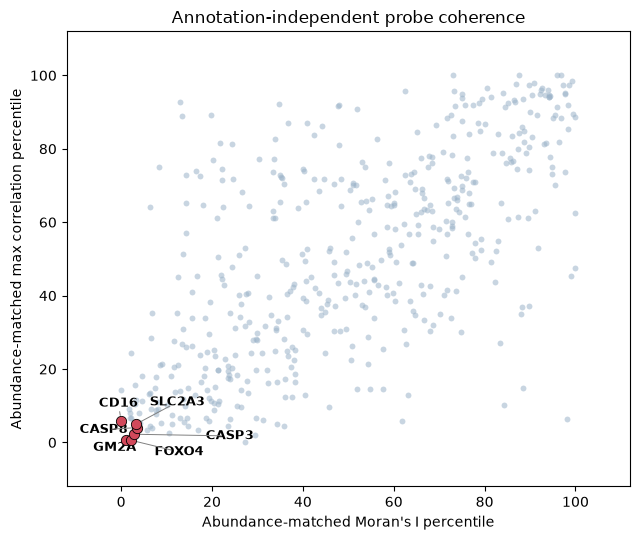

In [26]:
# run plots

fig = plot_ranked_probe_qc(
    ranked_report,
    label_genes=candidate_genes,
    save_path=OUTDIR / "ranked_probe_qc_scatter.png",
)

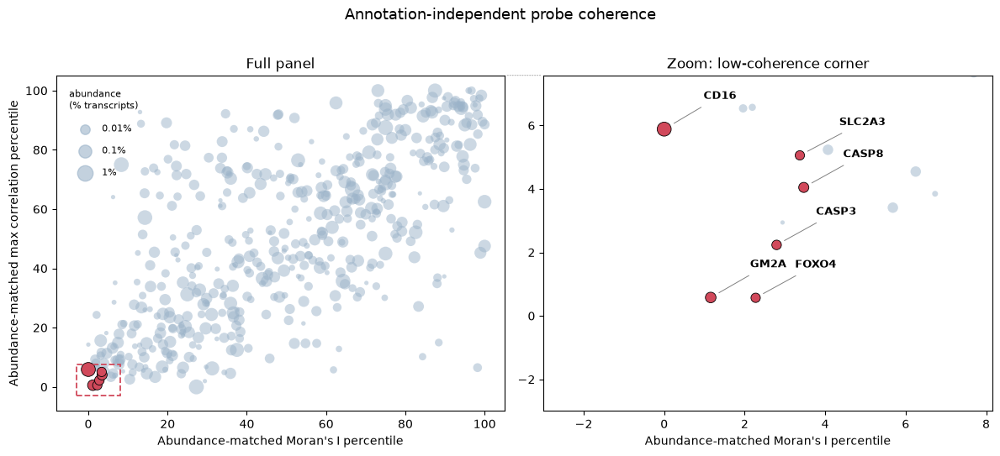

In [27]:
fig = plot_probe_qc_with_zoom(
    ranked_report,
    label_genes=["GM2A", "FOXO4", "CASP3", "CASP8", "CD16", "SLC2A3"],
    zoom_genes=["GM2A"],
    save_path=OUTDIR / "ranked_probe_qc_zoom.png",
)

In [28]:
#halo function helpers

#Refactored for shared 
# ---------------------------------------------------------------------------
def build_tissue_mask(cell_bin_x, cell_bin_y, nx, ny, min_cells_per_bin, fill_holes=True):
    cell_density = np.zeros((nx, ny), float)
    np.add.at(cell_density, (cell_bin_x, cell_bin_y), 1)
    tissue = cell_density >= min_cells_per_bin

    # remove lone squares
    tissue = ndimage.binary_opening(tissue, iterations=1)
    # fill in holes (kept optional here only because check_tissue_mask wants
    # to be able to turn this off for debugging; build_ring_counts always
    # calls this with fill_holes=True, matching its original behavior)
    if fill_holes:
        tissue = ndimage.binary_fill_holes(tissue)
    return tissue



def compute_captured_mask(sample_dir, x0, y0, bin_um, nx, ny):
    fov_file = json.loads((sample_dir / "aux_outputs" / "morphology_fov_locations.json").read_text())
    assert fov_file["units"] == "micron"
    captured = np.zeros((nx, ny), bool)
    for fov_box in fov_file["fov_locations"].values():
        bin_x_start = max(int((fov_box["x"] - x0) // bin_um), 0)
        bin_y_start = max(int((fov_box["y"] - y0) // bin_um), 0)
        bin_x_end = min(int((fov_box["x"] + fov_box["width"] - x0) // bin_um), nx - 1)
        bin_y_end = min(int((fov_box["y"] + fov_box["height"] - y0) // bin_um), ny - 1)
        captured[bin_x_start:bin_x_end + 1, bin_y_start:bin_y_end + 1] = True
    return captured


def build_ring_counts(sample_names, bin_um=BIN_UM, max_rings=MAX_RINGS, min_cells_per_bin=MIN_CELLS_PER_BIN):
    ring_counts = {}
    ring_bins = np.zeros(max_rings + 1, float)
    for sample in sample_names:
        transcript = load_transcripts_xy(sample)
        sample_dir = BASE_DIR / sample
        cells = read_cells_table(sample_dir)

        #load in positions
        c_x = cells["x_centroid"].to_numpy(float)
        c_y = cells["y_centroid"].to_numpy(float)
        transcript_x = transcript["x"].to_numpy(float)
        transcript_y = transcript["y"].to_numpy(float)

        #define grids(griddy)
        #bottom left
        x0 = min(transcript_x.min(), c_x.min())
        y0 = min(transcript_y.min(), c_y.min())
        #c_x - x0 is how far from left. // is finding which bin
        cell_bin_x = ((c_x - x0) // bin_um).astype(int)
        #same logic for y and for transcripts
        cell_bin_y = ((c_y - y0) // bin_um).astype(int)
        transcript_bin_x = ((transcript_x - x0) // bin_um).astype(int)
        transcript_bin_y = ((transcript_y - y0) // bin_um).astype(int)

        nx = int(max(cell_bin_x.max(), transcript_bin_x.max())) + 1
        ny = int(max(cell_bin_y.max(), transcript_bin_y.max())) + 1

        # decide which squares count as tissue
        # FIX: now calls the shared helper instead of inlining the same
        # logic that check_tissue_mask had quietly drifted from.
        tissue = build_tissue_mask(cell_bin_x, cell_bin_y, nx, ny, min_cells_per_bin, fill_holes=True)

        # FIX: figure out which bins were actually imaged, so we don't count
        # un-imaged area as valid "area" in the density denominator.
        captured = compute_captured_mask(sample_dir, x0, y0, bin_um, nx, ny)

        # distance from tissue, in bins
        ring = ndimage.distance_transform_edt(~tissue).astype(int)

        # FIX: ring_bins (area denominator) now only accumulates bins that are
        # BOTH within max_rings AND actually captured by an imaged FOV.
        # Before: ring_bins += np.bincount(ring[ring <= max_rings], ...)
        # which silently included un-imaged bins as if they were valid area.
        valid_area = captured & (ring <= max_rings)
        ring_clipped = ring[valid_area]
        ring_bins += np.bincount(ring_clipped, minlength=max_rings + 1).astype(float)

        transcript_ring = ring[transcript_bin_x, transcript_bin_y]

        # FIX: apply the same "captured" restriction to transcripts, so the
        # numerator (ring_counts) and denominator (ring_bins) are defined
        # over the identical set of bins. In practice transcripts should
        # already fall inside captured FOVs, but this guards against any
        # bin-edge mismatches right at the footprint boundary and makes the
        # restriction explicit/symmetric rather than implicit.
        transcript_captured = captured[transcript_bin_x, transcript_bin_y]
        keep = (transcript_ring <= max_rings) & transcript_captured
        gene = transcript["feature_name"].to_numpy()[keep]
        transcript_ring = transcript_ring[keep]

        # tally per gene and accumulate across samples
        tx_df = pd.DataFrame({"gene": gene, "ring": transcript_ring})
        for g, gene_rings in tx_df.groupby("gene")["ring"]:
            counts = np.bincount(gene_rings.to_numpy(), minlength=max_rings + 1)[:max_rings + 1].astype(float)
            ring_counts[g] = ring_counts.get(g, 0) + counts

    return ring_counts, ring_bins

#statistically identify how "flat" the gene is. You would expect there to be less RNA farther from tissue.
#find per gene ring counts. Calculate density in each ring. Average far ring densities(4-8) and divide by ring 2 density
def compute_flatness(ring_counts, ring_bins, max_rings=MAX_RINGS, min_total=MIN_TOTAL, min_ring2=MIN_RING2):
    ring_cols = [f"ring{r}" for r in range(max_rings+1)]
    gene_metrics = pd.DataFrame(ring_counts).T
    gene_metrics.columns = ring_cols
    gene_metrics["total"]=gene_metrics[ring_cols].sum(axis=1)
    enough_total = gene_metrics["total"] >= min_total
    enough_ring2 = gene_metrics["ring2"] >= min_ring2
    scored = enough_total & enough_ring2

    bins_per_ring = pd.Series(np.clip(ring_bins, 1, None), index=ring_cols)
    density = gene_metrics.loc[scored, ring_cols].div(bins_per_ring, axis=1)

    far_cols = [f"ring{r}" for r in range(4, max_rings + 1)]
    far_density = density[far_cols].mean(axis=1)
    ring2_density = density["ring2"].clip(lower=1e-9)
    flatness = far_density / ring2_density

    gene_metrics["flatness"] = np.nan
    gene_metrics.loc[scored, "flatness"] = flatness
    return gene_metrics

#computes the slope of the decay. Another useful metric of decay. Negative slope is expected for a normal gene as it decays fast.
#Not decaying fast or at all is likely a sign of something of something going wrong.
#didn't use gaussian bc it might predict negatives
#Basically it is fitting a lin to log(count) vs  ring. It is corrected for area so it is per-area density decay.
def decay_slope(gene_metrics, ring_bins, max_rings=MAX_RINGS):
    #Goes through rings 2->8 to calculate. Ring 1 is normally not very good due to it being too close to the boundary of cells and mask being imprecise
    fit_rings = list(range(2, max_rings + 1))
    #those nums are columns
    fit_cols = [f"ring{r}" for r in fit_rings]
    #rings as array. fit against this
    ring_index = np.array(fit_rings, dtype=float)
    #use log of area since its log of transcripts
    log_area = np.log(np.clip(ring_bins, 1, None))[fit_rings]
    X = sm.add_constant(ring_index)

    scored = gene_metrics["flatness"].notna()
    #set up the slope container.
    slope = pd.Series(np.nan, index=gene_metrics.index)

    #For only the scored genes(ones with enough counts)
    for gene in gene_metrics.index[scored]:
        y = gene_metrics.loc[gene, fit_cols].to_numpy(float)
        res = sm.GLM(y, X, family=sm.families.NegativeBinomial(), offset=log_area).fit()
        slope[gene] = res.params[1]
        #y = gene_metrics.loc[gene, fit_cols].to_numpy(float)
        # FIX: sm.GLM(..., family=NegativeBinomial()) fixes the dispersion
        # parameter alpha at 1.0 for EVERY gene instead of estimating it --
        # that's what the "alpha not set" warning was telling you. Gene
        # totals here vary hugely, so one fixed alpha is a poor assumption
        # for most genes. sm.NegativeBinomial (the discrete MLE model, not
        # the GLM family wrapper) estimates alpha jointly with the slope,
        # per gene, which is the statistically correct fix rather than just
        # silencing the warning.
        #try:
        #    res = sm.NegativeBinomial(y, X, offset=log_area).fit(disp=0)
        #    slope[gene] = res.params[1]
        #except Exception:
            # Some genes (very sparse far-ring counts) can fail to converge
            # under full NB MLE. Fall back to the fixed-alpha=1 GLM as a
            # safety net so one bad gene doesn't blow up the whole loop --
            # alpha=1.0 passed explicitly now, so this fallback path no
            # longer triggers the ValueWarning either.
         #   res = sm.GLM(y, X, family=sm.families.NegativeBinomial(alpha=1.0), offset=log_area).fit()
         #   slope[gene] = res.params[1]

    gene_metrics["slope"] = slope
    return gene_metrics

def compute_density(gene_metrics, ring_bins, max_rings=MAX_RINGS):
    ring_cols = [f"ring{r}" for r in range(max_rings + 1)]
    density_cols = [f"dens{r}" for r in range(max_rings + 1)]
    bins_per_ring = np.clip(ring_bins, 1, None)
    gene_metrics[density_cols] = gene_metrics[ring_cols].div(bins_per_ring, axis=1).to_numpy()
    return gene_metrics



def compute_percentiles(gene_metrics):
    gene_metrics["flatness_pct"] = gene_metrics["flatness"].rank(pct=True) * 100.0
    gene_metrics["slope_pct"] = gene_metrics["slope"].rank(pct=True) * 100.0
    return gene_metrics


def compute_magnitude(gene_metrics, max_rings=MAX_RINGS):
    far_cols = [f"ring{r}" for r in range(4, max_rings + 1)]
    scored = gene_metrics["flatness"].notna()
    gene_metrics["far_count"] = np.nan
    gene_metrics.loc[scored, "far_count"] = gene_metrics.loc[scored, far_cols].sum(axis=1)
    gene_metrics["offtissue_frac"] = np.nan
    gene_metrics.loc[scored, "offtissue_frac"] = (1.0 - gene_metrics.loc[scored, "ring0"] / gene_metrics.loc[scored, "total"].clip(lower=1))
    return gene_metrics

def assign_tiers(gene_metrics, flag_pct=95, min_far_count=400):
    gene_metrics["halo_call"] = "decays_normally"
    gene_metrics.loc[gene_metrics["flatness"].isna(), "halo_call"] = "insufficient_counts"

    flagged = (gene_metrics["flatness"] >= FLATNESS_CUTOFF) & (gene_metrics["slope"] >= SLOPE_CUTOFF) & (gene_metrics["far_count"] >= min_far_count)
    gene_metrics.loc[flagged, "halo_call"] = "nonspecific"

    gene_metrics["severity"] = np.where(flagged, gene_metrics["flatness"] * gene_metrics["far_count"], np.nan)
    return gene_metrics

def check_tissue_mask(sample, bin_um=BIN_UM, min_cells_per_bin=MIN_CELLS_PER_BIN,
                      fill_holes=True, level=-4, origin="lower"):
    ## FIX: now calls build_tissue_mask() / compute_captured_mask(), the same
    ## helpers build_ring_counts uses, instead of a hand-copied version that
    ## had drifted (it previously added an extra binary_closing step and
    ## duplicated the captured-mask logic inline). This guarantees the plot
    ## you're eyeballing matches what actually got scored.
    transcript = load_transcripts_xy(sample)
    sample_dir = BASE_DIR / sample
    cells = read_cells_table(sample_dir)

    # load in positions
    c_x = cells["x_centroid"].to_numpy(float)
    c_y = cells["y_centroid"].to_numpy(float)
    transcript_x = transcript["x"].to_numpy(float)
    transcript_y = transcript["y"].to_numpy(float)

    # define grids
    # bottom left
    x0 = min(transcript_x.min(), c_x.min())
    y0 = min(transcript_y.min(), c_y.min())
    cell_bin_x = ((c_x - x0) // bin_um).astype(int)
    cell_bin_y = ((c_y - y0) // bin_um).astype(int)
    transcript_bin_x = ((transcript_x - x0) // bin_um).astype(int)
    transcript_bin_y = ((transcript_y - y0) // bin_um).astype(int)

    nx = int(max(cell_bin_x.max(), transcript_bin_x.max())) + 1
    ny = int(max(cell_bin_y.max(), transcript_bin_y.max())) + 1

    # decide which squares count as tissue
    # FIX: was opening -> closing -> (optional) fill_holes here, vs.
    # opening -> (always) fill_holes in build_ring_counts. Now identical,
    # with fill_holes still toggleable for debugging purposes only.
    tissue = build_tissue_mask(cell_bin_x, cell_bin_y, nx, ny, min_cells_per_bin, fill_holes=fill_holes)

    ###################### LOAD IMAGING TO CHECK MASKING ######################
    #Panel 1 is dapi+mask overlaid + field of capture
    #Panel 2 is rings with no dapi + Field of capture
    #Bounding box
    mask_extent = [x0, x0 + nx * bin_um, y0, y0 + ny * bin_um]
    experiment = json.loads((sample_dir / "experiment.xenium").read_text())
    microns_per_pixel = experiment.get("pixel_size", 0.2125)

    #load dapi
    dapi_path = sample_dir / "morphology_focus" / "ch0000_dapi.ome.tif"
    with tifffile.TiffFile(dapi_path) as tif:
        image_series = tif.series[0]
        full_res_height = image_series.levels[0].shape[-2]
        full_res_width = image_series.levels[0].shape[-1]
        dapi_image = image_series.levels[level].asarray()

    if dapi_image.ndim == 3:
        channel_axis = int(np.argmin(dapi_image.shape))
        dapi_image = np.take(dapi_image, 0, axis=channel_axis)

    # FIX: reuse the shared helper (was duplicated inline before) so this is
    # guaranteed to be the exact same captured-area mask build_ring_counts uses.
    captured = compute_captured_mask(sample_dir, x0, y0, bin_um, nx, ny)

    ring = ndimage.distance_transform_edt(~tissue).astype(int)
    ring_display = ring.astype(float)
    ring_display[ring > MAX_RINGS] = np.nan
    ring_display[~captured] = np.nan

    def draw_outlines(panel, tissue_color):
        panel.contour(tissue.T, levels=[0.5], colors=tissue_color, linewidths=0.6,
                      extent=mask_extent, origin="lower")
        panel.contour(captured.T, levels=[0.5], colors="lime", linewidths=1.0,
                      extent=mask_extent, origin="lower")


    low_intensity, high_intensity = np.percentile(dapi_image, [1, 99.5])
    fig, ax = plt.subplots(figsize=(12, 8))

    ax.imshow(dapi_image, origin=origin, cmap="gray", vmin=low_intensity, vmax=high_intensity,
              extent=[0, full_res_width * microns_per_pixel, 0, full_res_height * microns_per_pixel])
    draw_outlines(ax, tissue_color="cyan")
    ax.set_title(f"{sample}\ntissue mask vs DAPI (fill_holes={fill_holes})")
    ax.set_xlabel("x (µm)"); ax.set_ylabel("y (µm)")

    ring_colormap = plt.get_cmap("turbo", MAX_RINGS + 1).copy()
    ring_colormap.set_bad("black")
    fig2, ax2 = plt.subplots(figsize=(12, 8))
    ring_image = ax2.imshow(ring_display.T, origin="lower", cmap=ring_colormap,
                            vmin=0, vmax=MAX_RINGS, extent=mask_extent, interpolation="nearest")
    draw_outlines(ax2, tissue_color="white")
    ax2.set_xlim(ax.get_xlim()); ax2.set_ylim(ax.get_ylim())
    ax2.set_title(f"{sample}\nring field masked to FOV footprint (clipped at {MAX_RINGS})")
    ax2.set_xlabel("x (µm)"); ax2.set_ylabel("y (µm)")
    fig2.colorbar(ring_image, ax=ax2, fraction=0.046, ticks=range(MAX_RINGS + 1), label="ring")

    return fig, ax

def halo_flatness(ring_counts, ring_bins):
    gene_metrics = compute_flatness(ring_counts, ring_bins)
    gene_metrics = compute_magnitude(gene_metrics)
    gene_metrics = decay_slope(gene_metrics, ring_bins)
    gene_metrics = compute_percentiles(gene_metrics)
    gene_metrics = compute_density(gene_metrics, ring_bins)
    gene_metrics = assign_tiers(gene_metrics)
    ring_cols = [f"ring{r}" for r in range(MAX_RINGS + 1)]
    density_cols = [f"dens{r}" for r in range(MAX_RINGS + 1)]
    column_order = (["halo_call", "severity",
                    "slope_pct", "flatness_pct",
                    "slope", "flatness",
                    "far_count", "offtissue_frac", "total"]+ring_cols + density_cols)
    return gene_metrics[column_order].sort_values("severity", ascending=False)

In [29]:
def decay_slope(gene_metrics, ring_bins, max_rings=MAX_RINGS):
    """
    Estimate spatial decay of transcript density away from tissue.

    Fits rings 2 through max_rings. Ring 0 is tissue and ring 1 is
    excluded because it is especially sensitive to tissue-mask boundary
    imprecision.

    The model includes log(area) as an offset so the slope reflects
    change in transcript density rather than raw transcript counts.

    A more negative slope indicates stronger decay away from tissue.
    Slopes near zero or positive indicate relatively flat/persistent
    off-tissue signal and may warrant further inspection.
    """

    fit_rings = list(range(2, max_rings + 1))
    fit_cols = [f"ring{r}" for r in fit_rings]

    ring_index = np.array(fit_rings, dtype=float)

    # Correct for the amount of captured/imaged area in each ring
    log_area = np.log(
        np.clip(ring_bins, 1, None)
    )[fit_rings]

    X = sm.add_constant(ring_index)

    scored = gene_metrics["flatness"].notna()

    slope = pd.Series(
        np.nan,
        index=gene_metrics.index,
        dtype=float
    )

    for gene in gene_metrics.index[scored]:

        y = gene_metrics.loc[
            gene,
            fit_cols
        ].to_numpy(dtype=float)

        try:
            # Estimate NB dispersion independently for each gene
            res = sm.NegativeBinomial(
                y,
                X,
                offset=log_area
            ).fit(disp=0)

            slope.loc[gene] = res.params[1]

        except Exception as e:
            # Fallback for sparse genes / convergence failures
            try:
                res = sm.GLM(
                    y,
                    X,
                    family=sm.families.NegativeBinomial(alpha=1.0),
                    offset=log_area
                ).fit()

                slope.loc[gene] = res.params[1]

            except Exception:
                print(f"Could not fit decay model for {gene}: {e}")
                slope.loc[gene] = np.nan

    gene_metrics["slope"] = slope

    return gene_metrics

In [30]:
all_sample_dirs = sorted(p.name for p in BASE_DIR.iterdir() if p.is_dir())
dirs_with_matrix = {p.parent.name for p in BASE_DIR.rglob("cell_feature_matrix.h5")}

print("dirs containing 'xen51':")
for name in all_sample_dirs:
    if "xen51" in name:
        print("  ", name, " matrix:", name in dirs_with_matrix)

print("\ndirs containing '10011':")
for name in all_sample_dirs:
    if "10011" in name:
        print("  ", name, " matrix:", name in dirs_with_matrix)

print(f"\n{len(all_sample_dirs)} dirs total, {len(dirs_with_matrix)} with a matrix")
print("dirs lacking a matrix:", [n for n in all_sample_dirs if n not in dirs_with_matrix])

print("\nSAMPLES entries with no matching dir:")
print([s for s in SAMPLES if s not in set(all_sample_dirs)])

dirs containing 'xen51':
   xen51A_935-10337__S-2407-003050_1  matrix: True
   xen51B_935-10337__S-2407-003050_2  matrix: True
   xen51_29-10011__S-1910-000072  matrix: True
   xen51_30-10044__S-1908-009670  matrix: True
   xen51_31-10001__S-1908-000922  matrix: True
   xen51_31-10035__S-1910-000166  matrix: True
   xen51_KPMP057__S-2211-003961  matrix: True

dirs containing '10011':
   xen47_29-10011__S-1910-000072  matrix: True
   xen51_29-10011__S-1910-000072  matrix: True

128 dirs total, 129 with a matrix
dirs lacking a matrix: ['ANALYSIS']

SAMPLES entries with no matching dir:
[]


### generate masks for decay/halo

Checking: xen51_29-10011__S-1910-000072


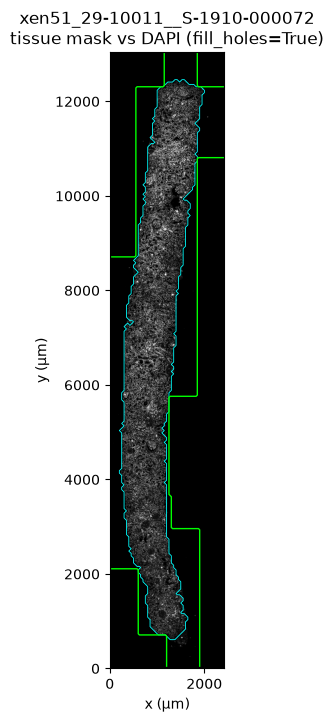

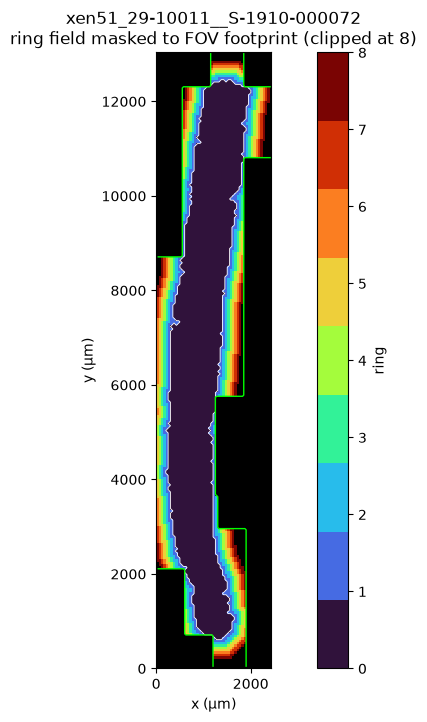

Checking: xen51_31-10035__S-1910-000166


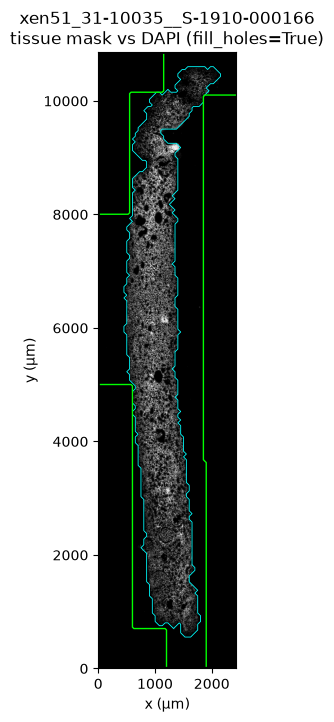

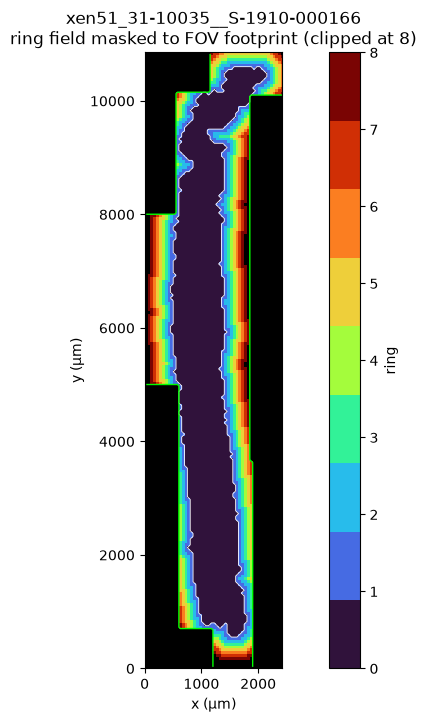

Checking: xen59B_936-10110__S-2412-000200_2


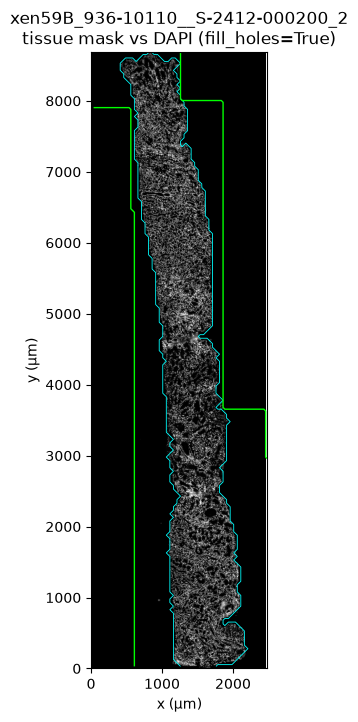

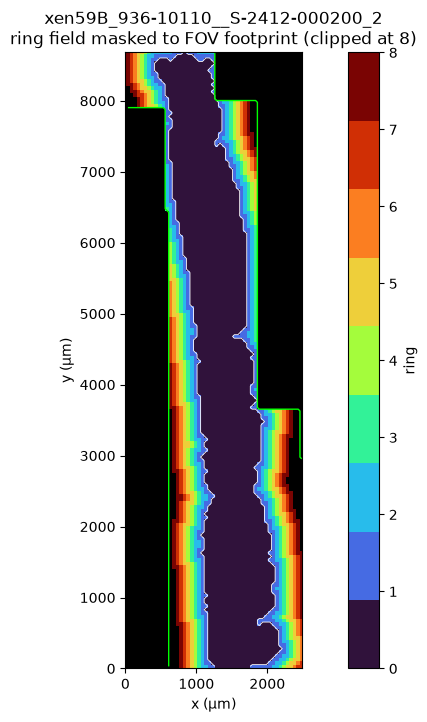

Checking: xen48_29-10277__S-2006-002227


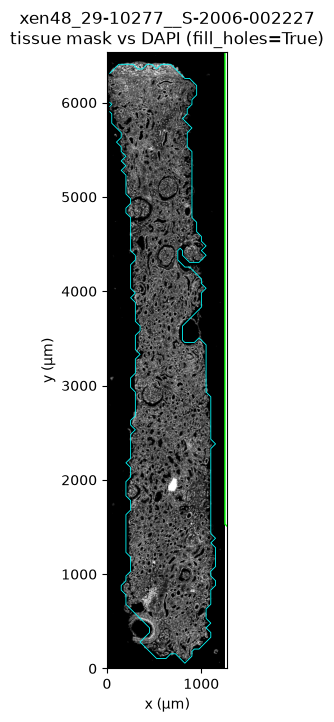

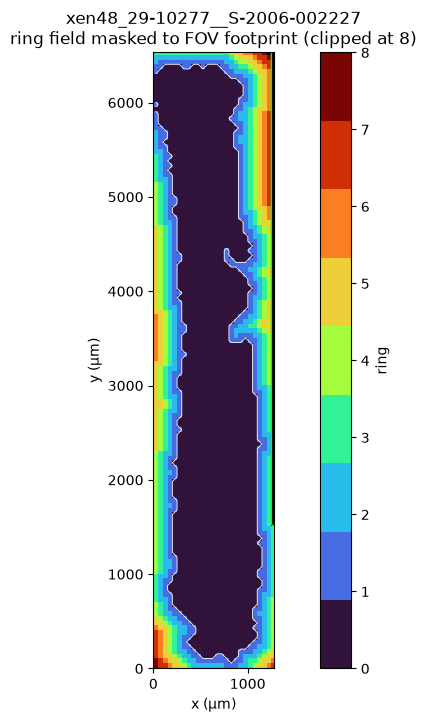

Checking: xen48_28-12263__S-1905-018622


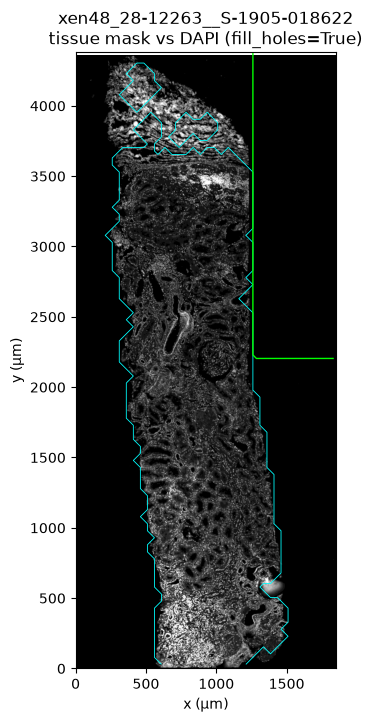

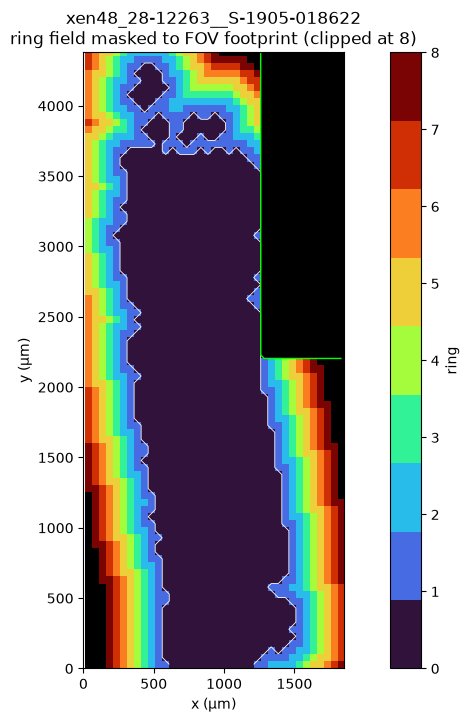

Checking: xen48_27-10042__S-2006-002168


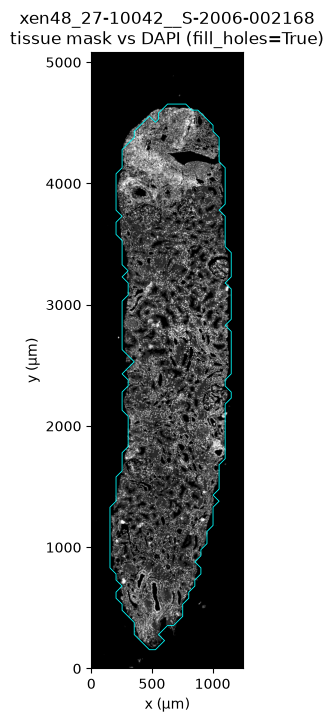

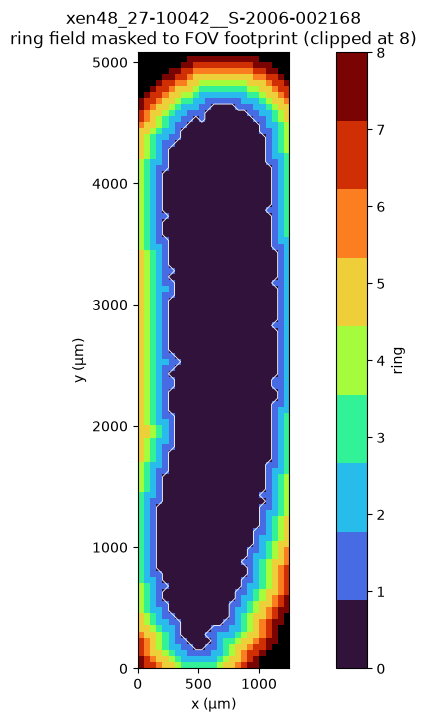

Checking: xen51_31-10001__S-1908-000922


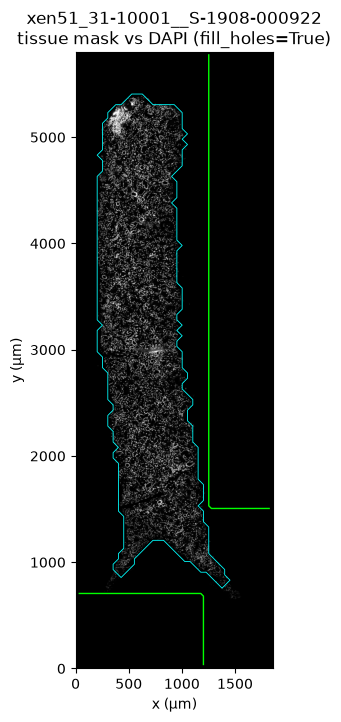

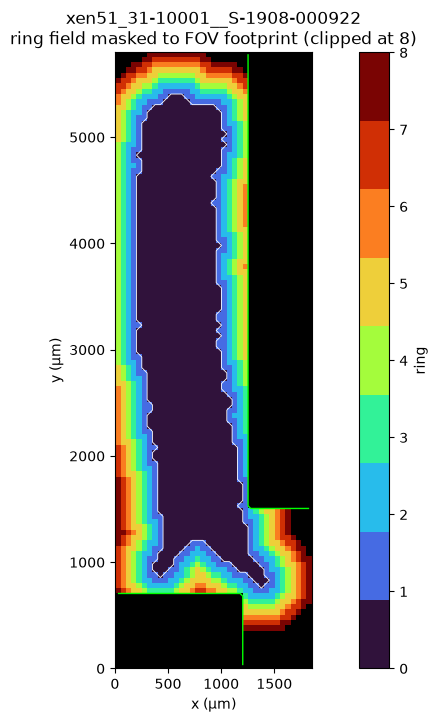

Checking: xen54B_29-11453__S-2501-010355_2


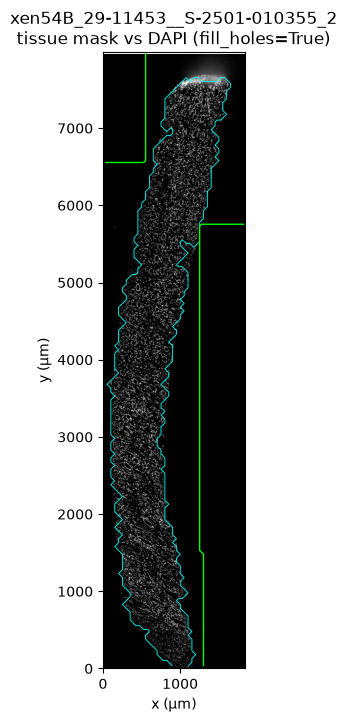

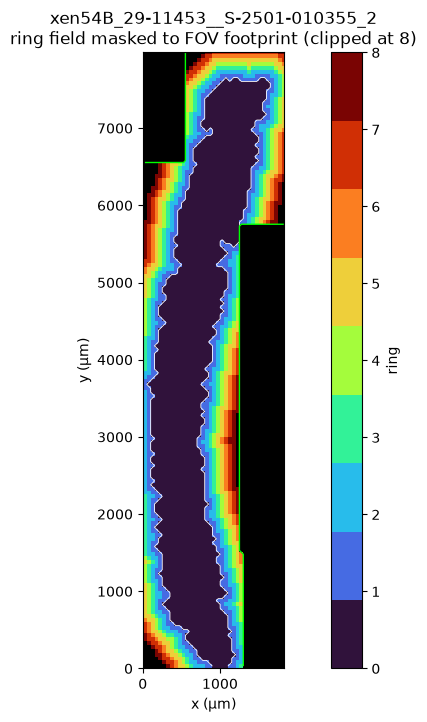

Checking: xen55_935-10530__S-2502-007510


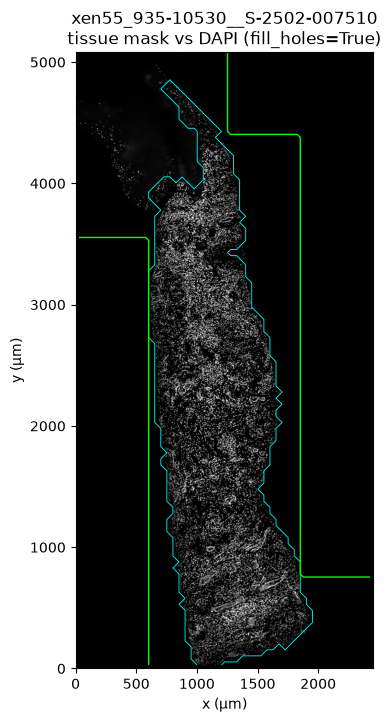

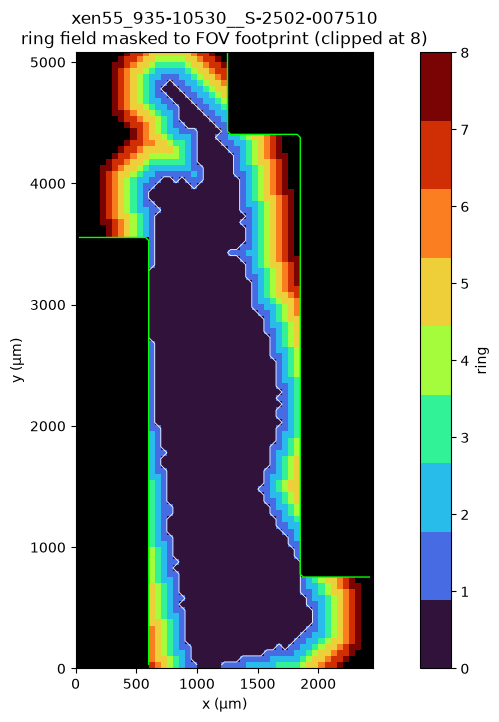

Checking: xen54_164-7__S-2108-005538


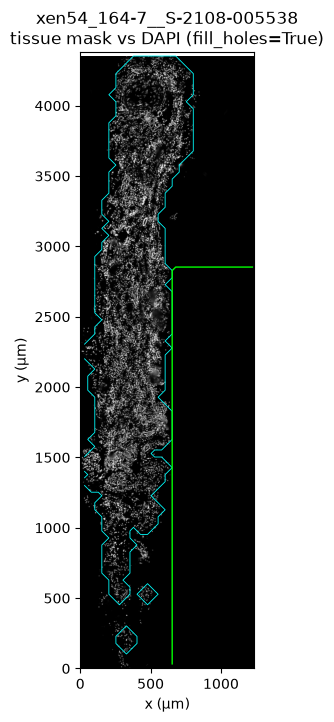

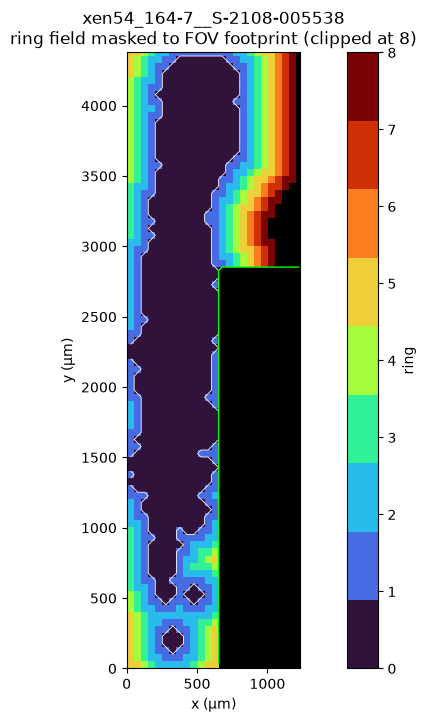

Checking: xen53_934-10141__S-2503-003165


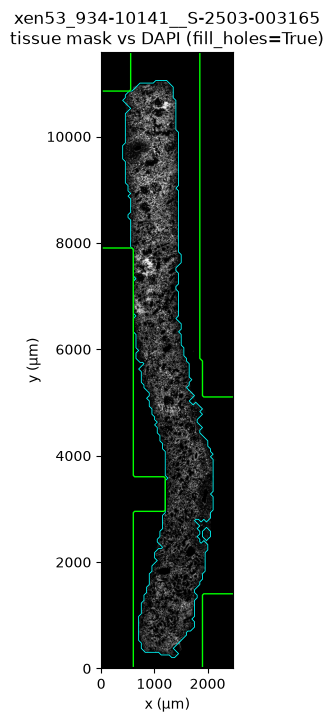

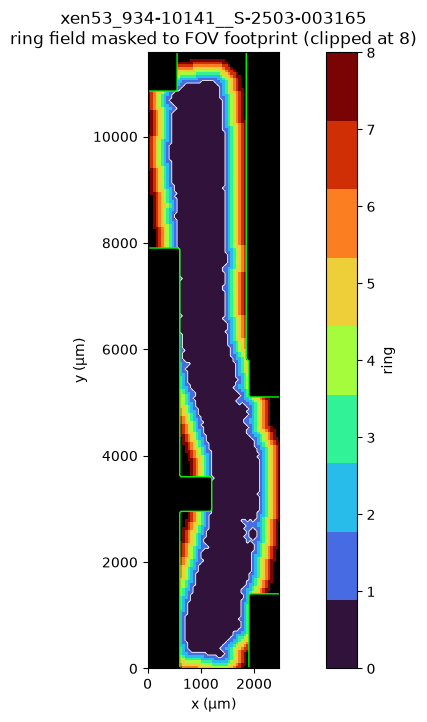

Checking: xen37_31-10105


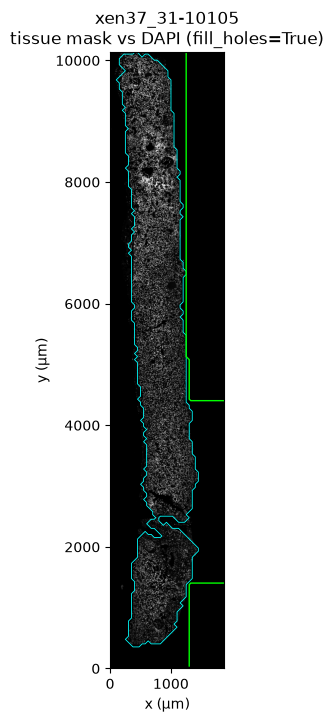

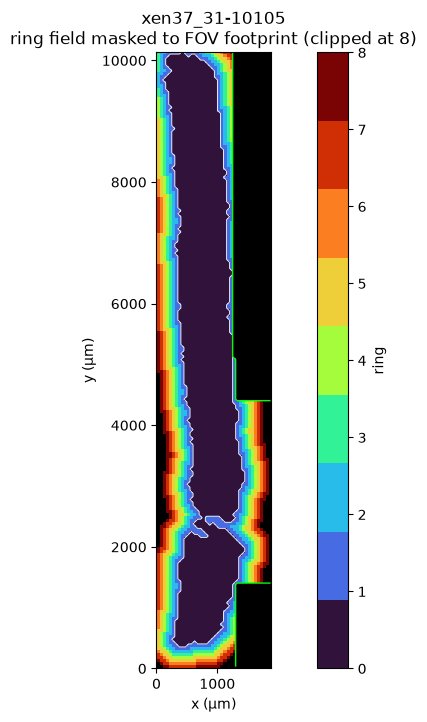

Checking: xen37_31-10236


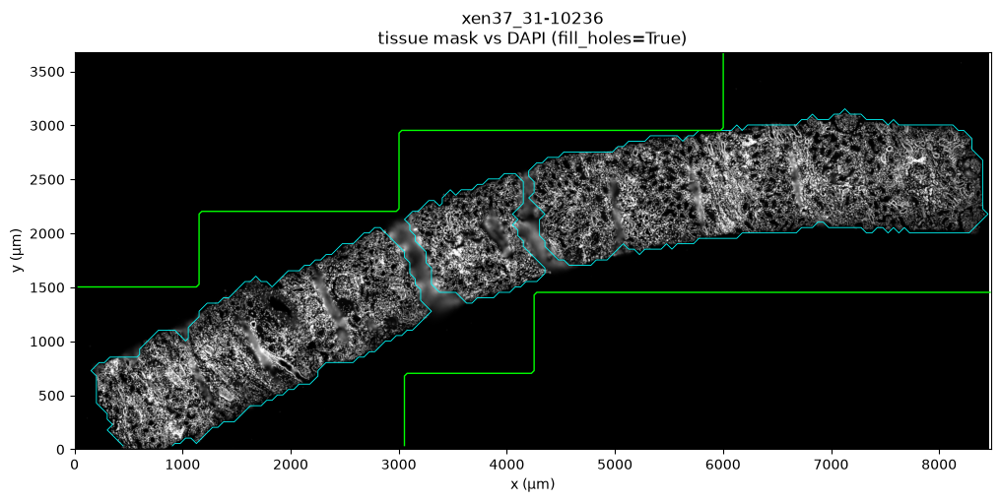

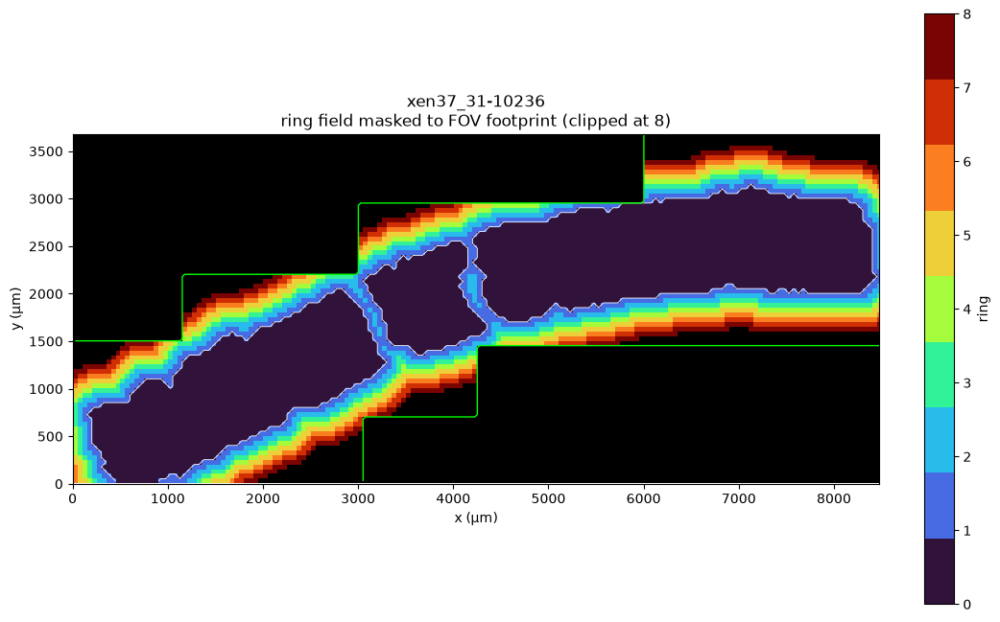

Checking: xen53_933-11034__S-2409-010084


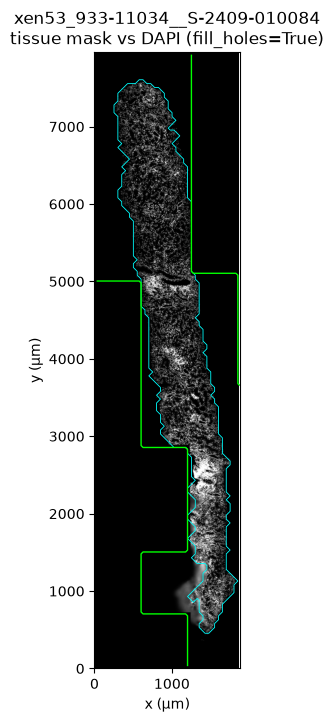

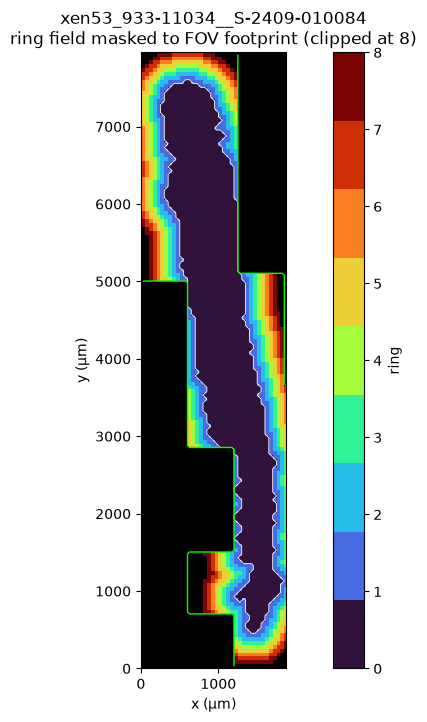

Checking: xen38_164-17


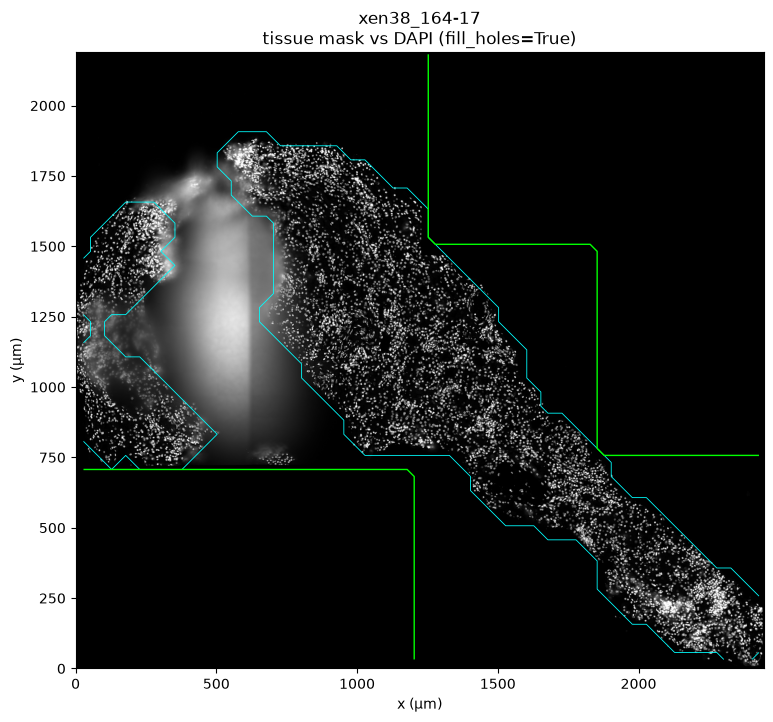

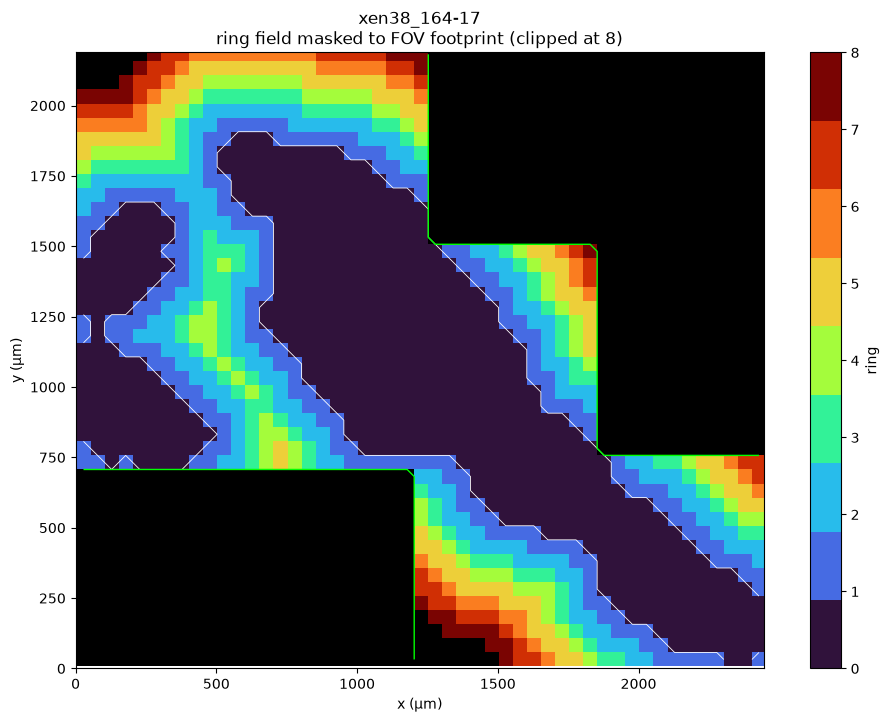

Checking: xen55_936-10746__S-2501-007962


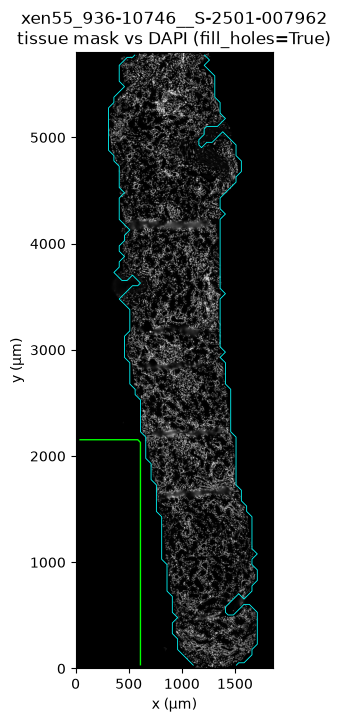

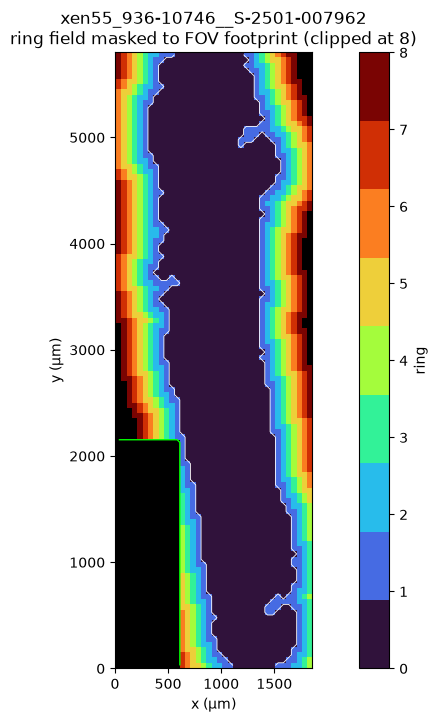

Checking: xen56_164-3__S-2008-006714


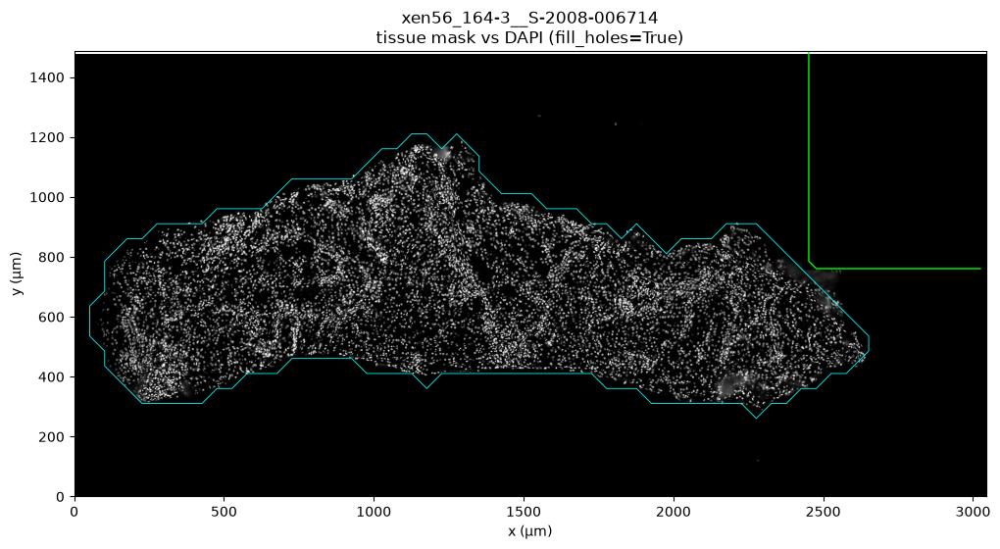

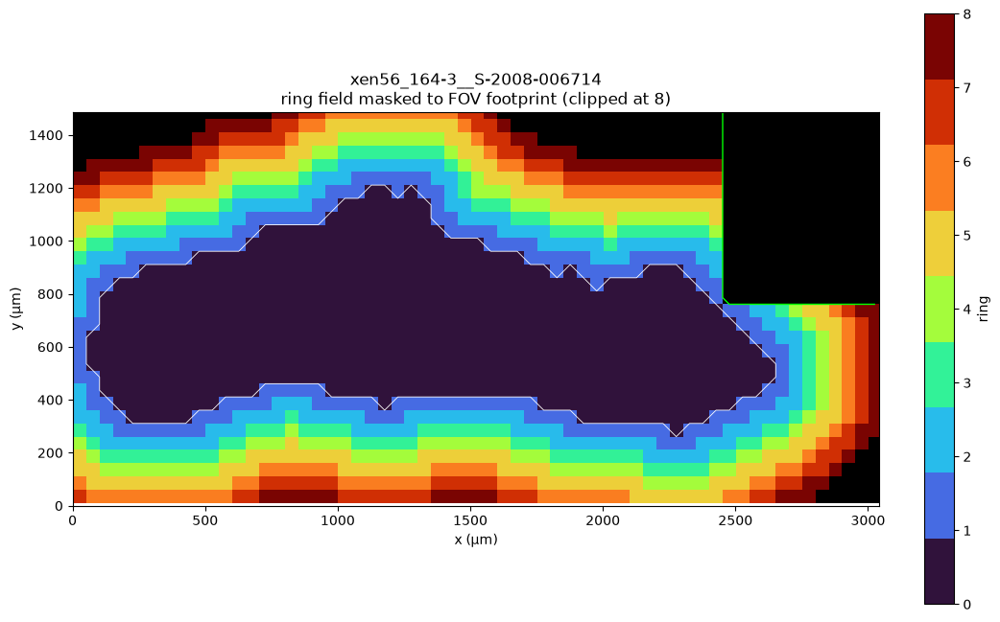

Checking: xen38_31-10100


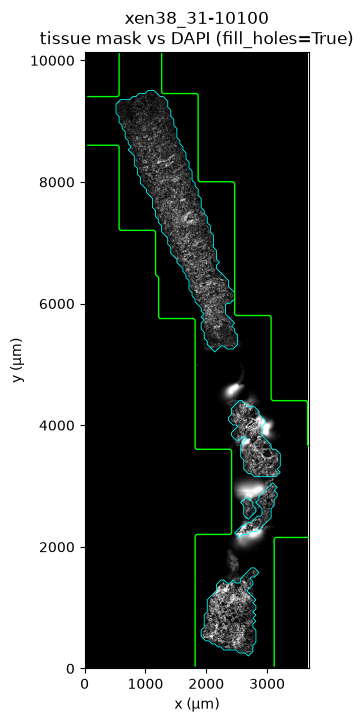

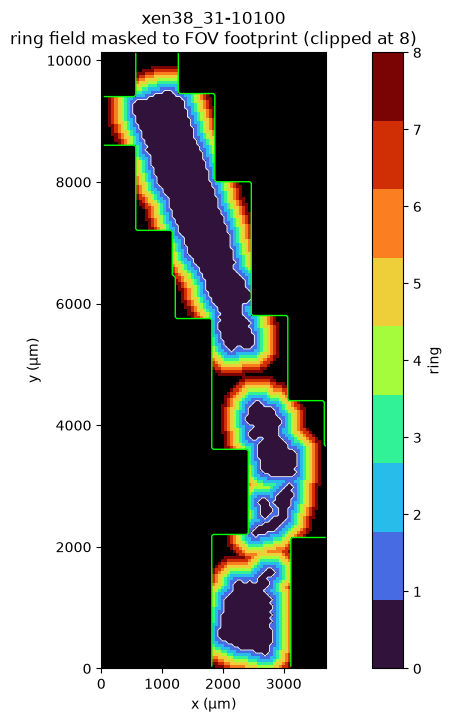

Checking: xen41_164-21


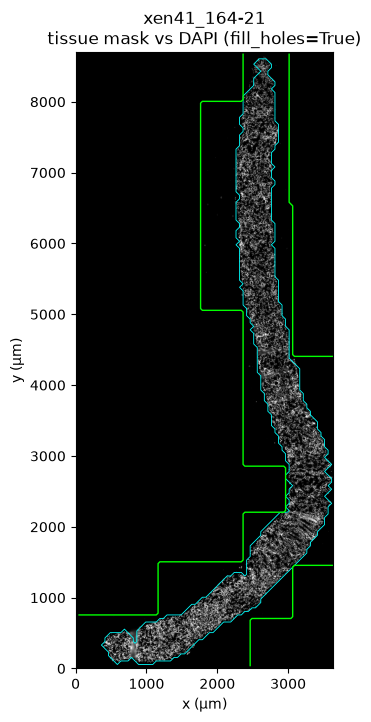

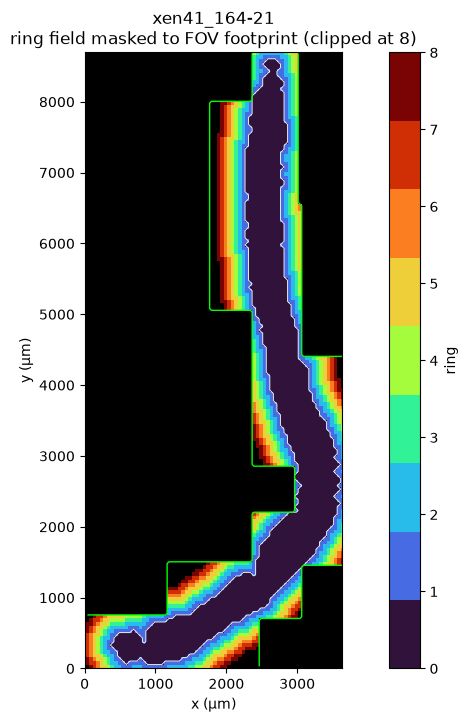

Checking: xen41_29-10010


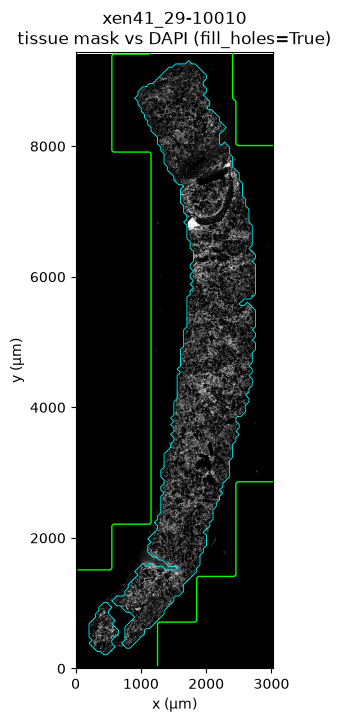

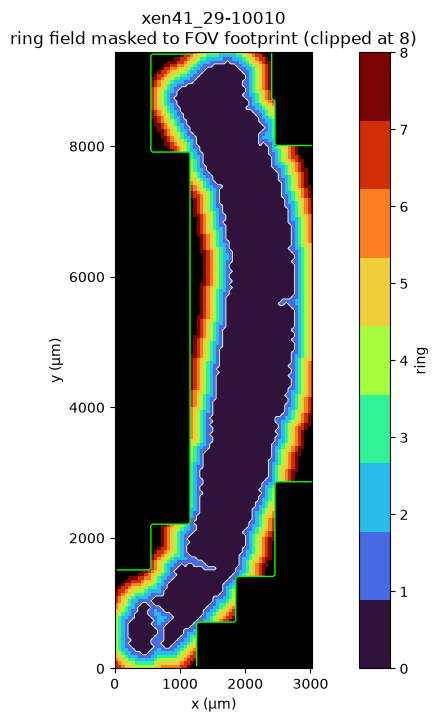

Checking: xen41_29-10404


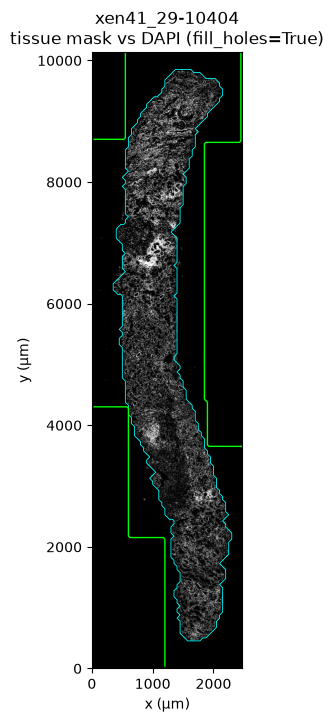

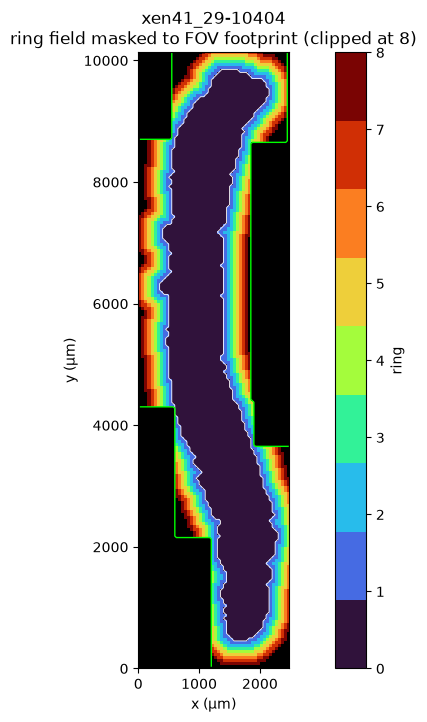

Checking: xen37_28-12510


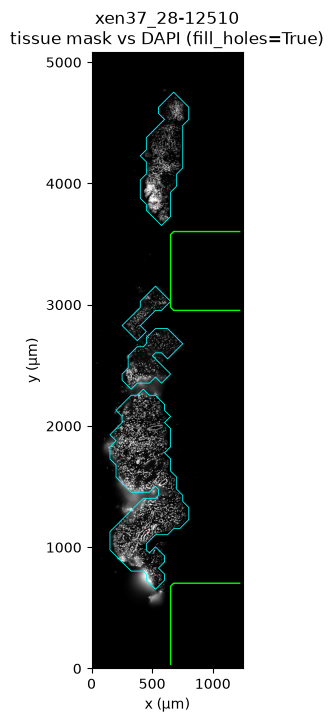

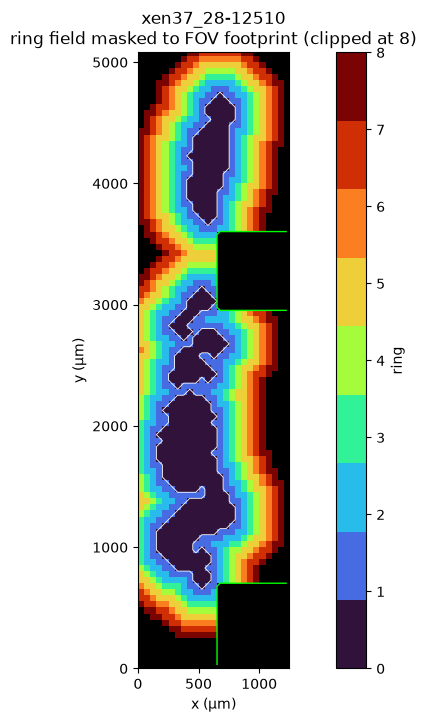

Checking: xen37_29-10395


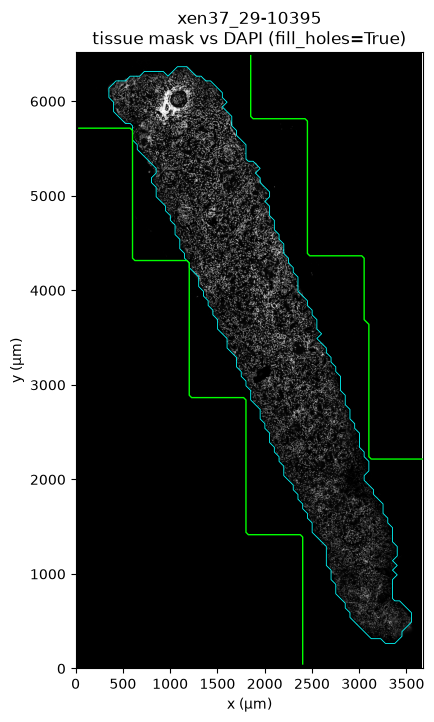

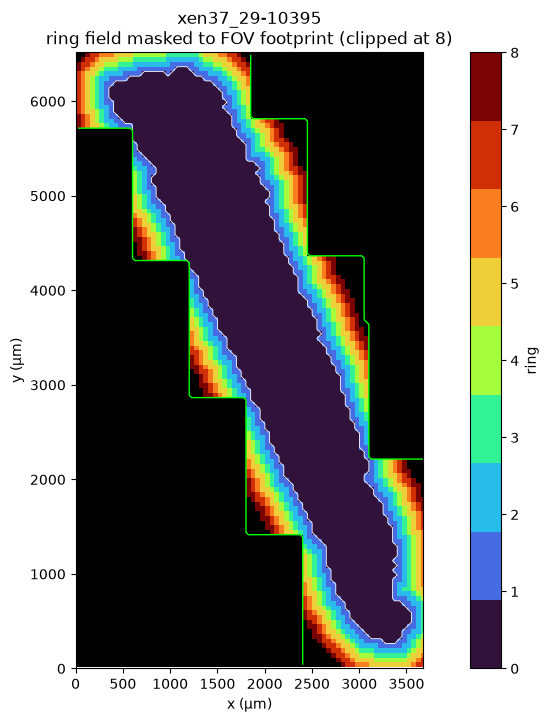

Checking: xen50_164-5__S-2008-006724


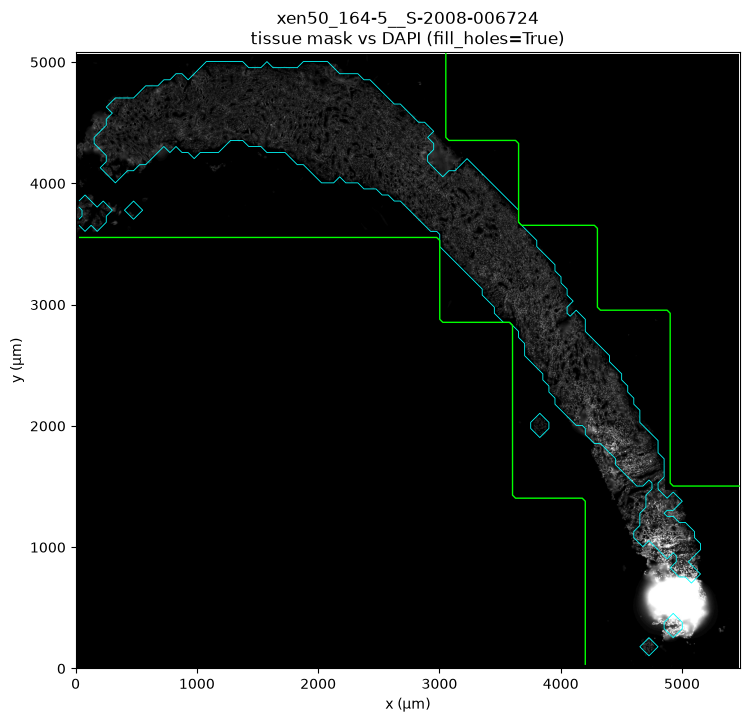

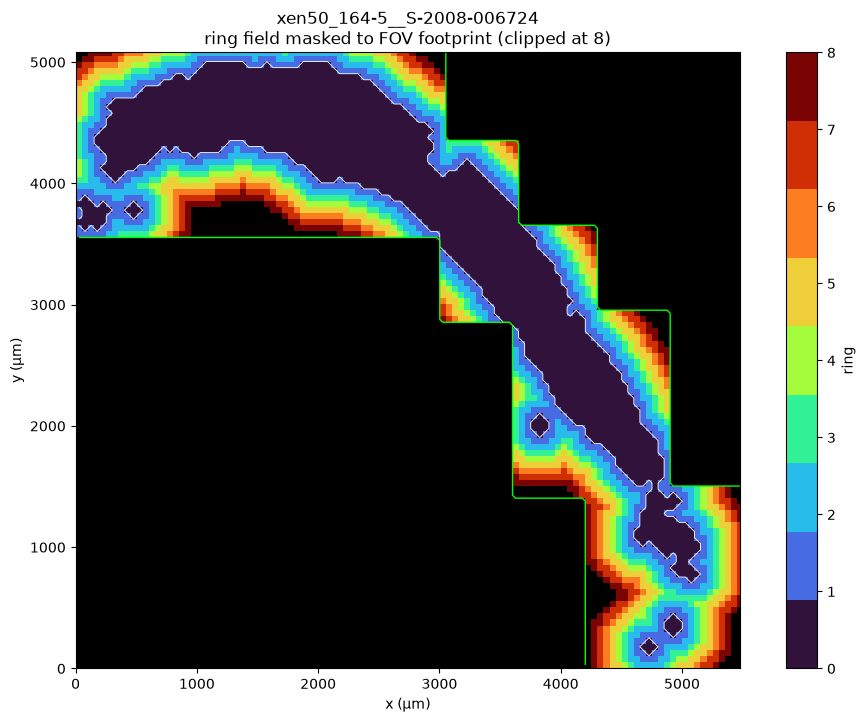

Checking: xen49_164-1__S-2008-006019


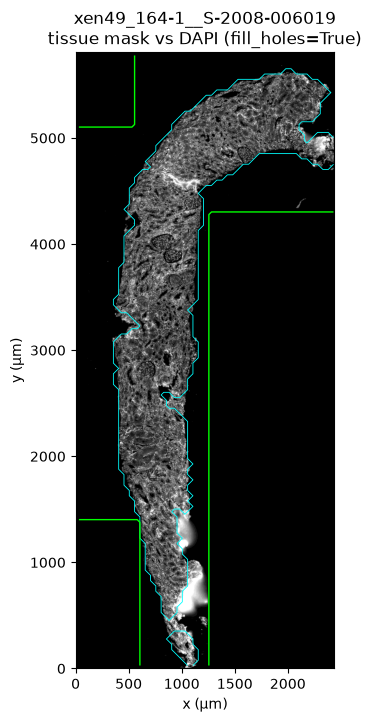

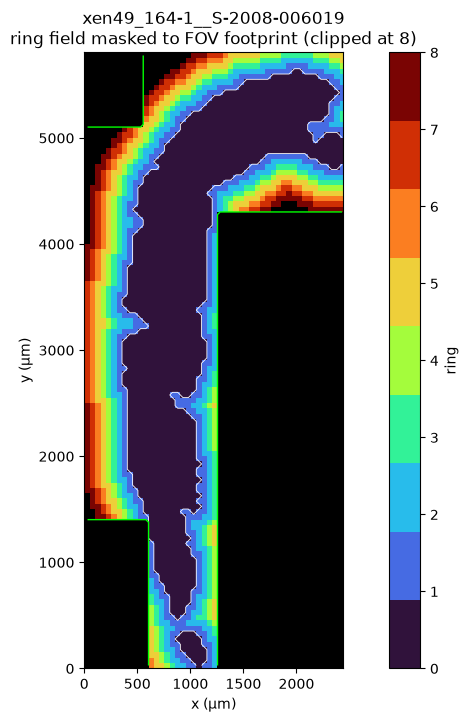

Checking: xen42_936-10948


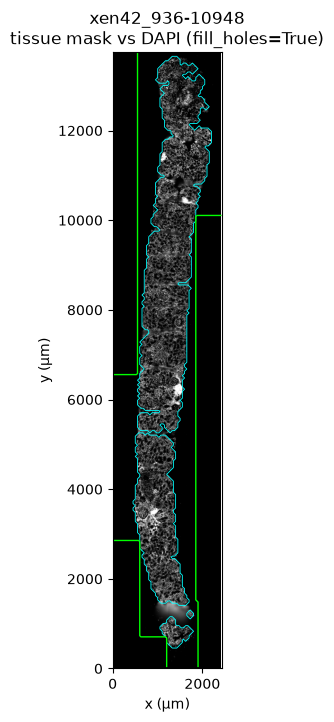

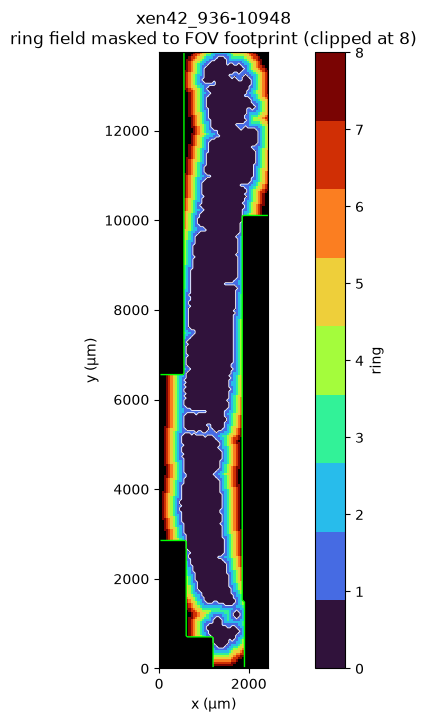

Checking: xen47_31-10000__S-1908-000877


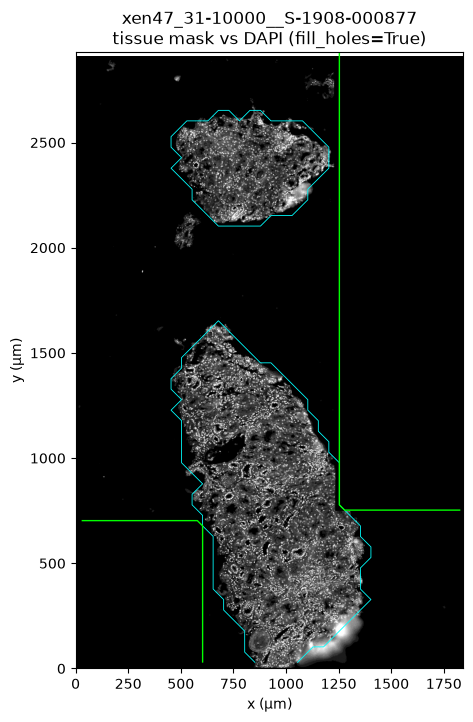

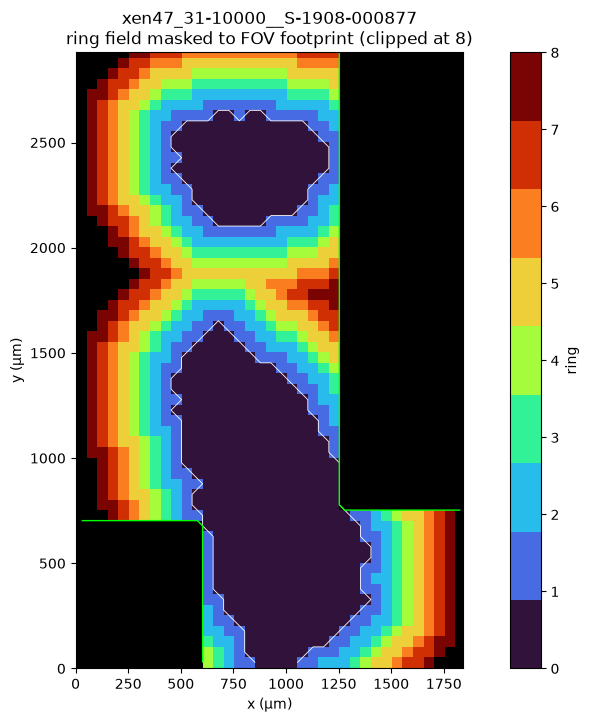

Checking: xen53_29-11429__S-2410-011790


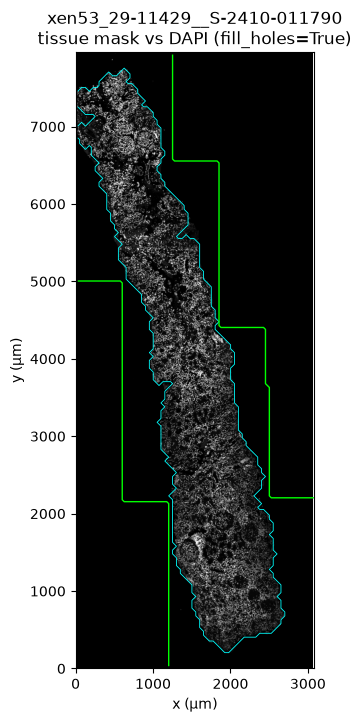

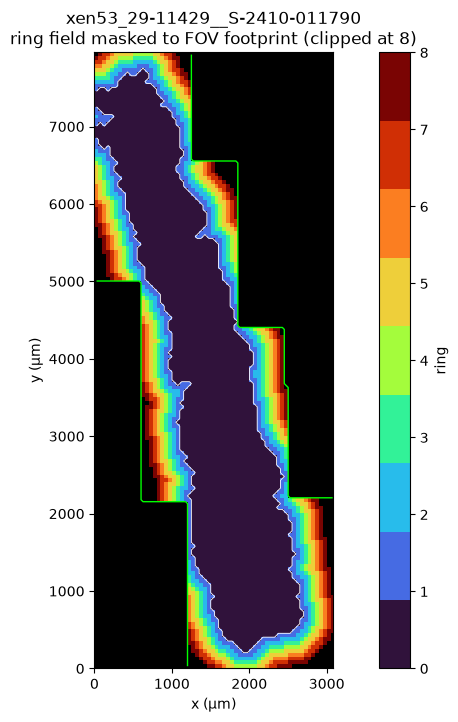

Checking: xen41_935-10542


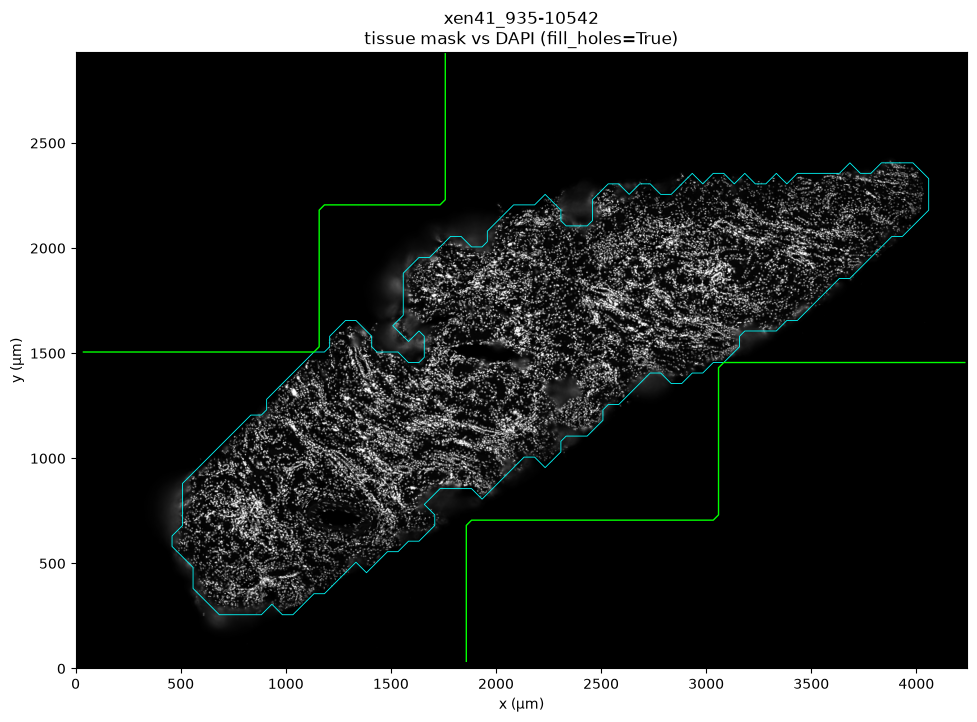

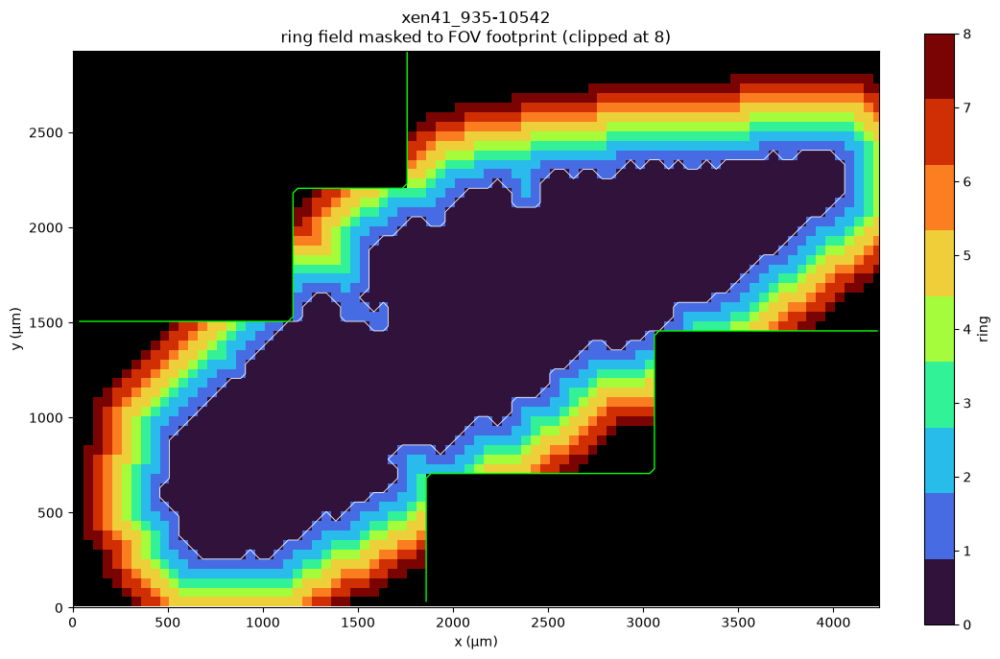

Checking: xen42_27-10154


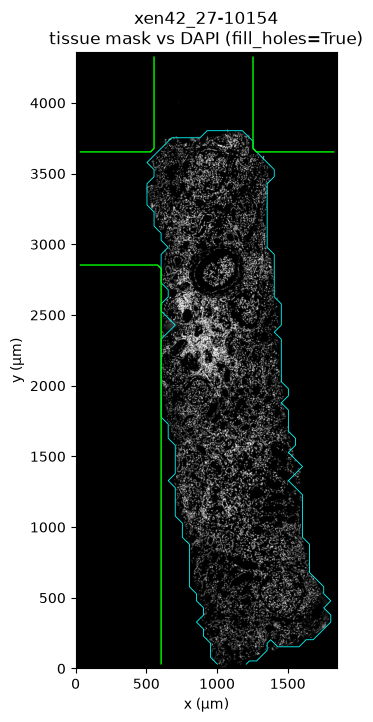

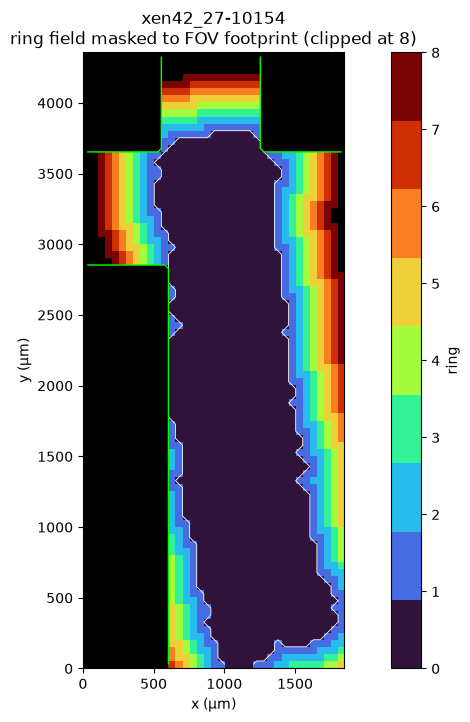

Checking: xen42_28-10051


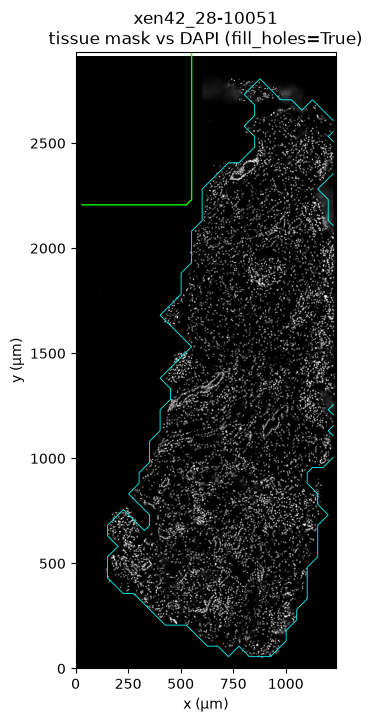

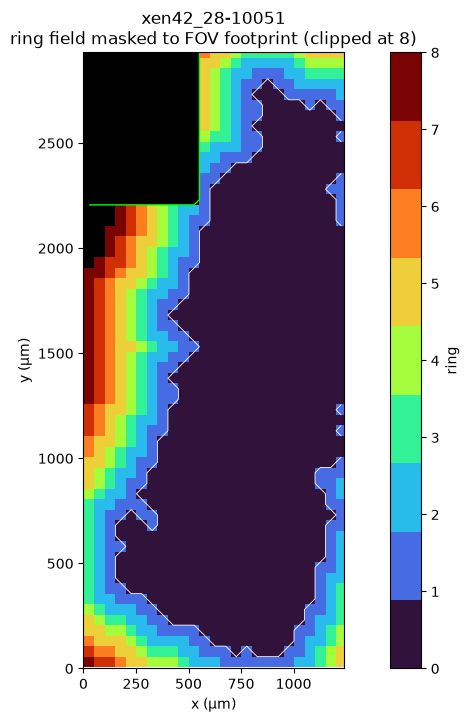

Checking: xen53_31-10864__S-2412-005705


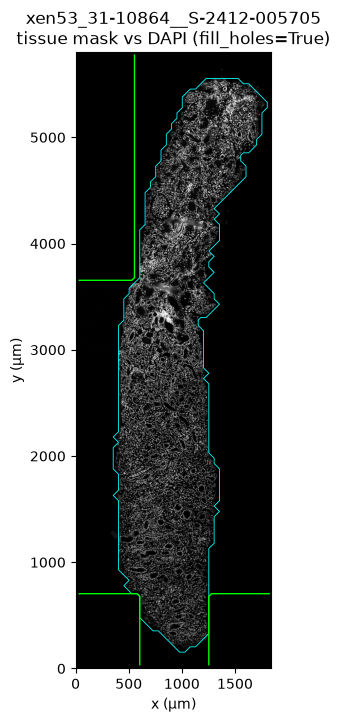

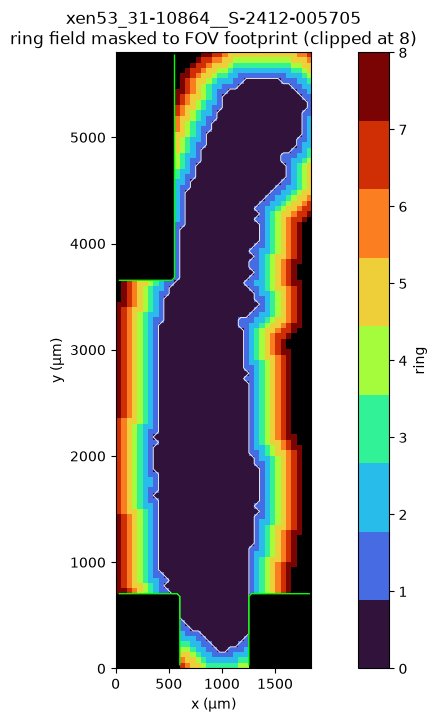

Checking: xen53_31-11370__S-2412-005611


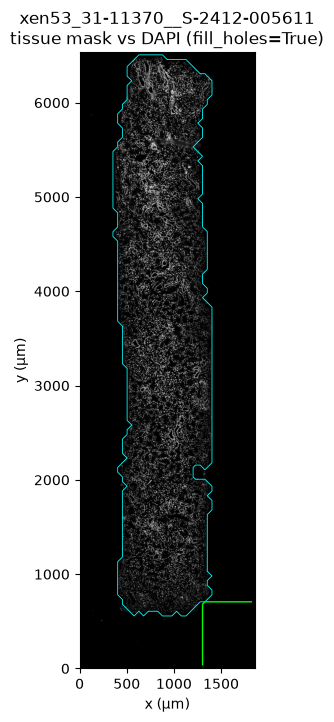

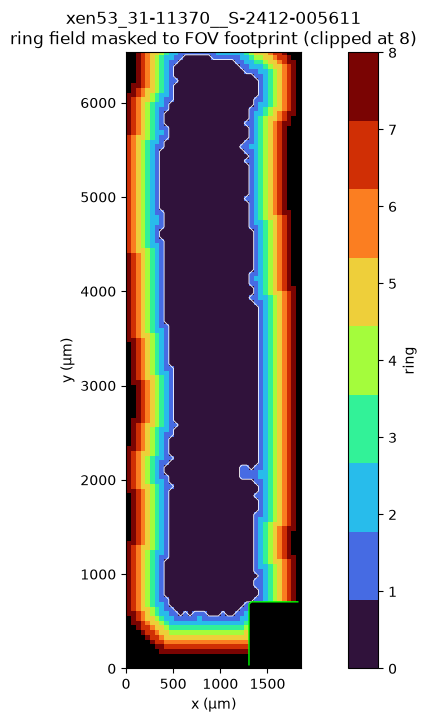

Checking: xen31_3781__K2200084_7__173010


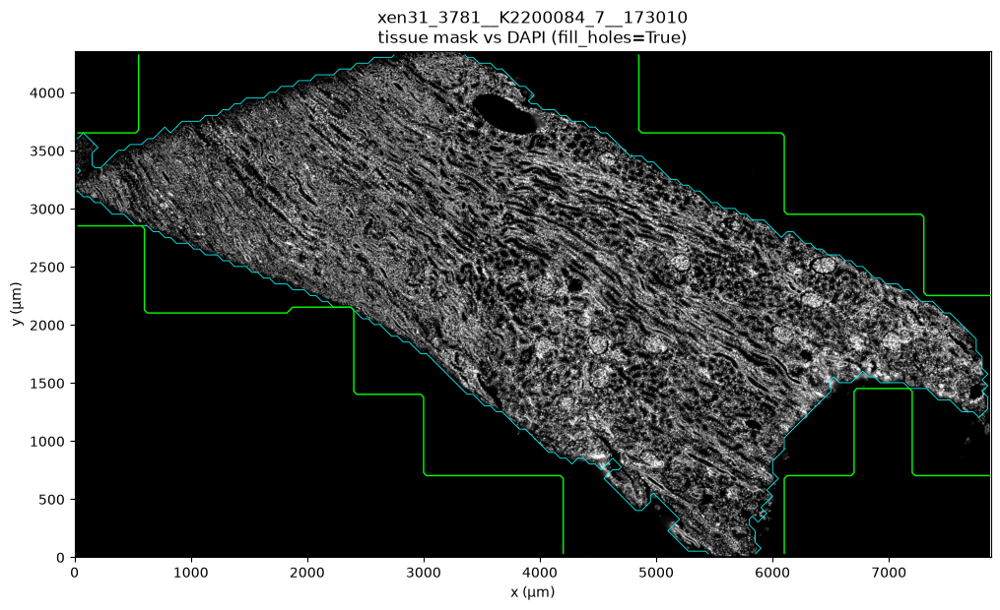

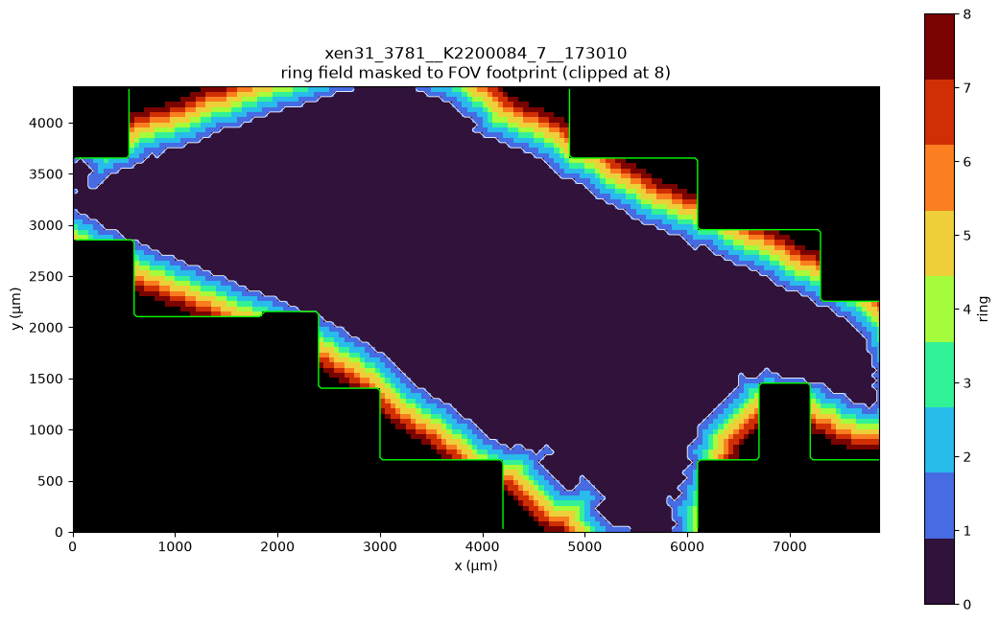

Checking: xen31_3990__K2300317_6__173009


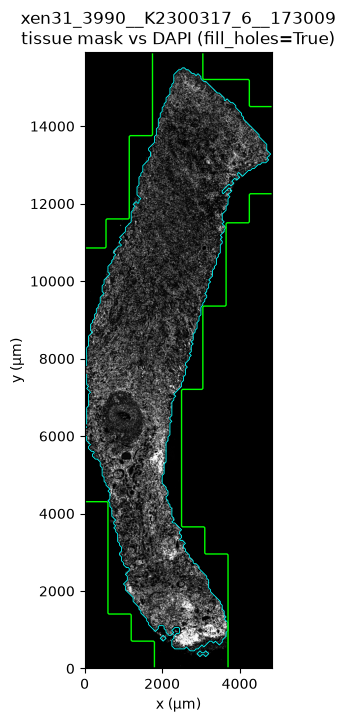

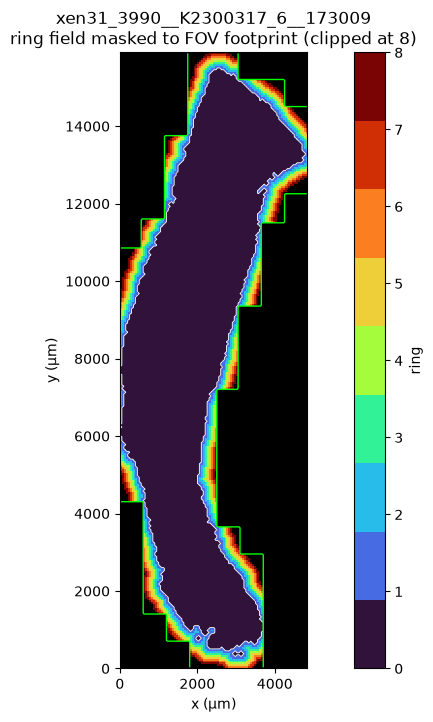

Checking: xen31_KPMP038__S-2211-003960__173010


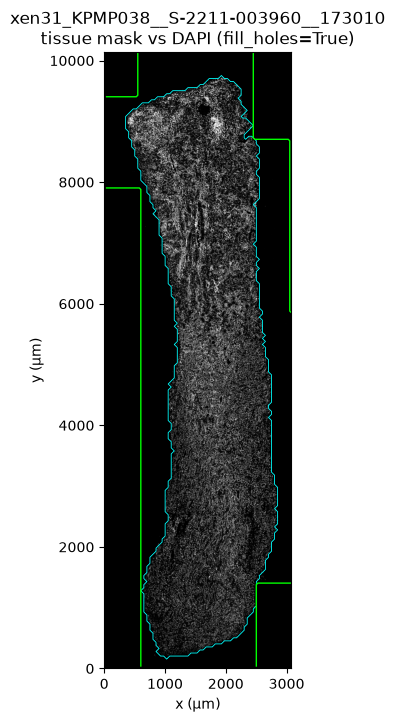

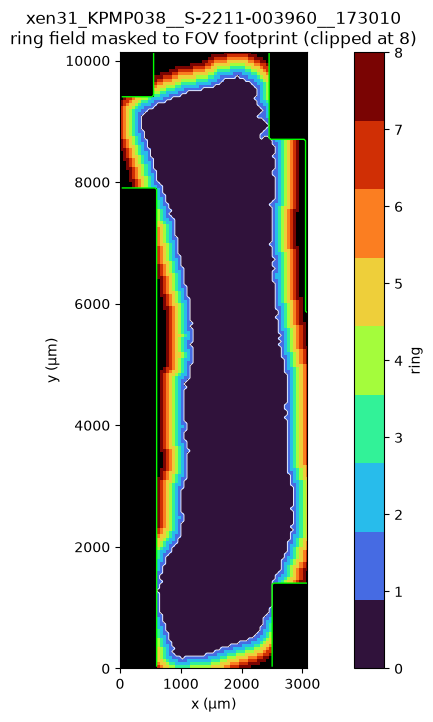

Checking: xen32_KPMP101__S-2211-003972__173010


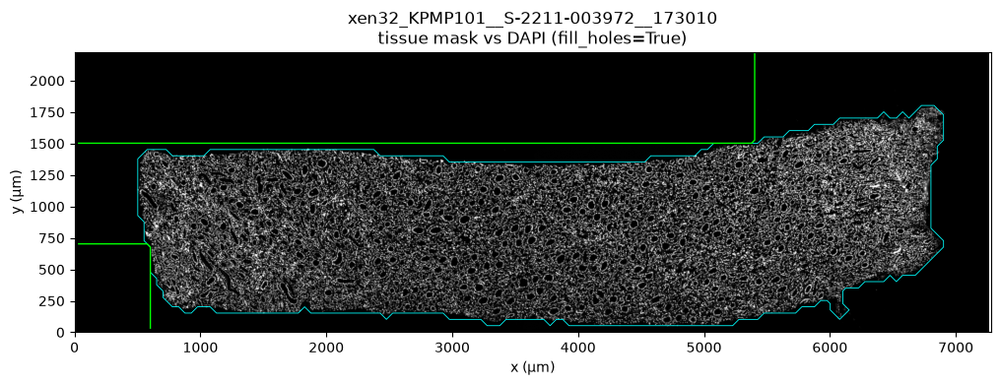

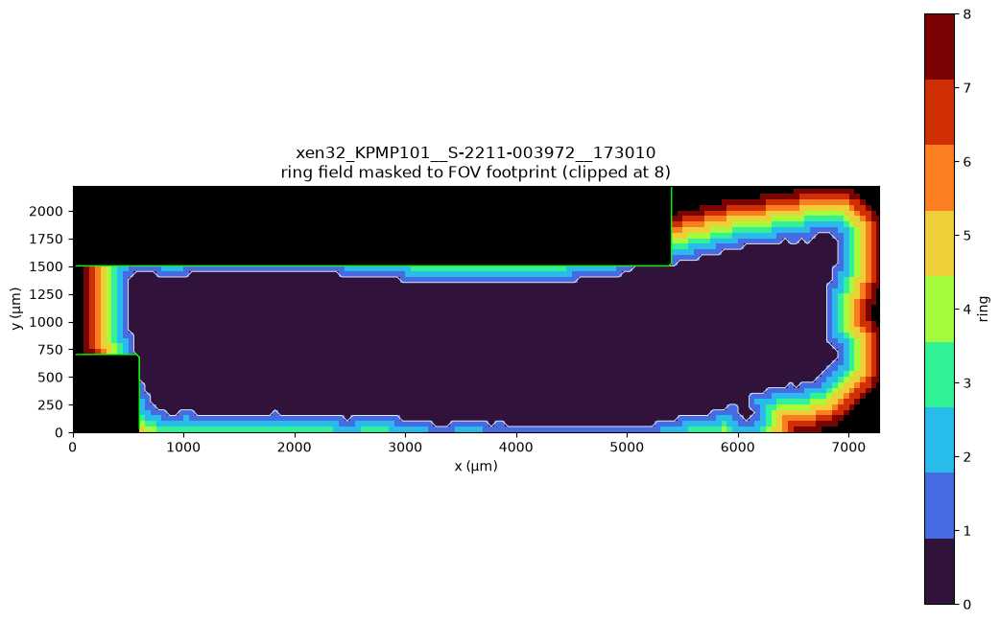

In [31]:
# Check tissue masks / ring construction visually.
# check_tissue_mask() creates two figures:
#   1. DAPI + tissue/capture boundary
#   2. distance rings + capture boundary

for sample in SAMPLES:

    print(f"Checking: {sample}")

    fig, ax = check_tissue_mask(sample)

    # Displays both figures created inside check_tissue_mask()
    plt.show()

    # Close BOTH figures before moving to the next sample
    plt.close("all")

In [32]:
# ------------------------------------------------------------
# BUILD DISTANCE-RING COUNTS
# ------------------------------------------------------------

ring_counts, ring_bins = build_ring_counts(SAMPLES)

# Load feature types for identifying controls
FEATURE_TYPE.update(
    load_feature_types(BASE_DIR / SAMPLES[0])
)

print("Number of features:", len(ring_counts))

print("\nNumber of captured bins per ring:")
for i, n in enumerate(ring_bins):
    print(f"Ring {i}: {int(n):,}")

Number of features: 541

Number of captured bins per ring:
Ring 0: 95,916
Ring 1: 15,296
Ring 2: 12,933
Ring 3: 9,322
Ring 4: 8,353
Ring 5: 9,494
Ring 6: 6,451
Ring 7: 6,237
Ring 8: 5,458


In [33]:
## only look at halo results
result = halo_flatness(ring_counts, ring_bins)



/storage2/fs1/sanjayjain/Active/spatial_Jain_lab/envs/resolvi_scvi_gpu/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/storage2/fs1/sanjayjain/Active/spatial_Jain_lab/envs/resolvi_scvi_gpu/lib/python3.11/site-packages/statsmodels/base/model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '
/storage2/fs1/sanjayjain/Active/spatial_Jain_lab/envs/resolvi_scvi_gpu/lib/python3.11/site-packages/statsmodels/base/model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '
/storage2/fs1/sanjayjain/Active/spatial_Jain_lab/envs/resolvi_scvi_gpu/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum L

In [34]:
gene_metrics = halo_flatness(ring_counts, ring_bins)
display(gene_metrics.head(20))

/storage2/fs1/sanjayjain/Active/spatial_Jain_lab/envs/resolvi_scvi_gpu/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/storage2/fs1/sanjayjain/Active/spatial_Jain_lab/envs/resolvi_scvi_gpu/lib/python3.11/site-packages/statsmodels/base/model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '
/storage2/fs1/sanjayjain/Active/spatial_Jain_lab/envs/resolvi_scvi_gpu/lib/python3.11/site-packages/statsmodels/base/model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '
/storage2/fs1/sanjayjain/Active/spatial_Jain_lab/envs/resolvi_scvi_gpu/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum L

,halo_call,severity,slope_pct,flatness_pct,slope,flatness,far_count,offtissue_frac,total,ring0,...,ring8,dens0,dens1,dens2,dens3,dens4,dens5,dens6,dens7,dens8
UMOD,nonspecific,6850.314413,97.077244,97.703549,-0.143093,0.523204,13093.0,0.009311,8155276.0,8079346.0,...,1522.0,84.233559,3.243201,0.669064,0.490882,0.428469,0.435644,0.318555,0.288761,0.278857
SLC12A1,nonspecific,4857.724931,96.868476,97.494781,-0.146381,0.522955,9289.0,0.006642,9008556.0,8948721.0,...,1009.0,93.297479,2.694038,0.472048,0.346814,0.283611,0.333579,0.224771,0.207472,0.184866
DEFB1,nonspecific,1612.299922,93.319415,96.033403,-0.172135,0.462375,3487.0,0.007678,3096371.0,3072597.0,...,380.0,32.034249,1.070280,0.200340,0.142137,0.113732,0.120918,0.084173,0.074715,0.069623
KCNJ1,nonspecific,1127.650916,93.528184,97.077244,-0.171541,0.477010,2364.0,0.006270,2527011.0,2511166.0,...,258.0,26.180887,0.713585,0.130751,0.093864,0.075183,0.087424,0.056115,0.045855,0.047270
JCHAIN,nonspecific,1063.172295,94.572025,96.659708,-0.165442,0.472521,2250.0,0.014557,786927.0,775472.0,...,243.0,8.084908,0.443449,0.127813,0.082493,0.084640,0.064462,0.057200,0.051146,0.044522
WFDC2,nonspecific,934.178461,91.440501,95.615866,-0.177794,0.453925,2058.0,0.006826,2073794.0,2059639.0,...,203.0,21.473362,0.643371,0.119539,0.076164,0.065007,0.075627,0.051155,0.042328,0.037193
SMAD9,nonspecific,779.407203,99.791232,99.791232,-0.061478,0.697144,1118.0,0.030903,123970.0,120139.0,...,157.0,1.252544,0.117612,0.044383,0.036473,0.031605,0.031388,0.029918,0.033029,0.028765
NegControlProbe_00012,nonspecific,356.607297,100.000000,100.000000,-0.044909,0.788954,452.0,0.385515,2651.0,1629.0,...,71.0,0.016984,0.015690,0.015928,0.013302,0.013648,0.011692,0.015346,0.009139,0.013008
MZB1,nonspecific,355.552189,98.329854,99.582463,-0.122190,0.580968,612.0,0.009343,315864.0,312913.0,...,67.0,3.262365,0.117547,0.028300,0.018773,0.021190,0.018643,0.015346,0.014751,0.012276
MX1,nonspecific,334.934047,98.747390,98.538622,-0.118298,0.534185,627.0,0.010516,468220.0,463296.0,...,63.0,4.830226,0.240978,0.032475,0.020489,0.017239,0.016115,0.028213,0.013628,0.011543


In [35]:
display(
    gene_metrics.sort_values("far_count", ascending=False).head(20)
)

,halo_call,severity,slope_pct,flatness_pct,slope,flatness,far_count,offtissue_frac,total,ring0,...,ring8,dens0,dens1,dens2,dens3,dens4,dens5,dens6,dens7,dens8
BAX,decays_normally,NaN,88.308977,84.551148,-0.191328,0.371706,74594.0,0.017304,30101261.0,29580377.0,...,8595.0,308.398776,22.577340,5.405474,3.329543,2.615827,2.219507,1.861727,1.774411,1.574753
UMOD,nonspecific,6850.314413,97.077244,97.703549,-0.143093,0.523204,13093.0,0.009311,8155276.0,8079346.0,...,1522.0,84.233559,3.243201,0.669064,0.490882,0.428469,0.435644,0.318555,0.288761,0.278857
AQP1,decays_normally,NaN,77.661795,73.277662,-0.219921,0.331035,10999.0,0.010009,10912701.0,10803481.0,...,1273.0,112.634816,5.335055,0.891054,0.546235,0.411349,0.323573,0.269881,0.236813,0.233236
GATM,decays_normally,NaN,83.089770,85.386221,-0.207411,0.377010,9690.0,0.010589,8969034.0,8874062.0,...,1125.0,92.519100,4.686323,0.689399,0.502467,0.357117,0.287971,0.241513,0.206830,0.206119
SLC12A1,nonspecific,4857.724931,96.868476,97.494781,-0.146381,0.522955,9289.0,0.006642,9008556.0,8948721.0,...,1009.0,93.297479,2.694038,0.472048,0.346814,0.283611,0.333579,0.224771,0.207472,0.184866
AQP2,decays_normally,NaN,90.814196,88.935282,-0.183451,0.395720,8745.0,0.008878,6005203.0,5951888.0,...,1005.0,62.053130,2.159127,0.598082,0.408603,0.297857,0.254161,0.232367,0.214847,0.184133
SPP1,decays_normally,NaN,88.517745,89.561587,-0.191195,0.400201,8657.0,0.010962,6907293.0,6831574.0,...,946.0,71.224551,3.668083,0.579139,0.371701,0.308991,0.265115,0.219191,0.192240,0.173324
CXCL14,decays_normally,NaN,78.288100,82.254697,-0.219002,0.361051,5379.0,0.010737,4428240.0,4380693.0,...,577.0,45.672182,2.263141,0.396969,0.259279,0.201724,0.164841,0.130832,0.113516,0.105716
PCK1,decays_normally,NaN,62.421712,59.916493,-0.238634,0.306457,5371.0,0.011279,5484416.0,5422557.0,...,538.0,56.534436,3.148666,0.464780,0.248337,0.194062,0.174531,0.125562,0.119448,0.098571
PDZK1IP1,decays_normally,NaN,72.442589,74.947808,-0.225576,0.338803,4614.0,0.008488,6413092.0,6358656.0,...,496.0,66.294007,2.804720,0.364881,0.236215,0.175266,0.133347,0.114246,0.104377,0.090876


In [37]:
# Inspect results, sorted by severity (already done inside halo_flatness)
#need to remove severit or halo call metric

# Genes flagged as likely non-specific / "halo" signal
gene_metrics[gene_metrics["halo_call"] == "nonspecific"]

# Save if you want a persistent copy
gene_metrics.to_csv(OUTDIR / "halo_flatness.csv")

In [40]:
print("CD16 in result:", "CD16" in result.index)
print("CD16 in ring_counts:", "CD16" in ring_counts)

print("\nAnything containing CD16:")
print([g for g in result.index if "CD16" in str(g).upper()])

print("\nPossible canonical equivalents:")
for g in ["CD16", "FCGR3A", "FCGR3B"]:
    print(g, "in result:", g in result.index)

CD16 in result: False
CD16 in ring_counts: False

Anything containing CD16:
['CD163', 'CD163L1']

Possible canonical equivalents:
CD16 in result: False
FCGR3A in result: True
FCGR3B in result: True


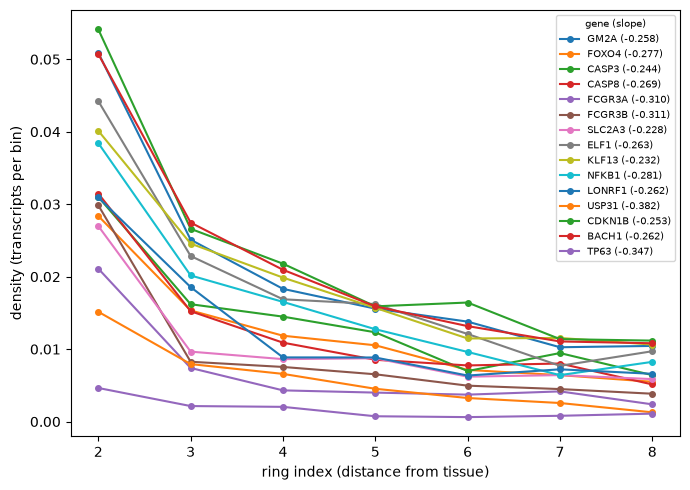

In [41]:
####Use this to visualize density across rings. Rings 0 and 1 are not used due to masking being imperfect.
GENES = [
    "GM2A",
    "FOXO4",
    "CASP3",
    "CASP8",
    "FCGR3A",
    "FCGR3B",
    "SLC2A3",
    "ELF1",
    "KLF13",
    "NFKB1",
    "LONRF1",
    "USP31",
    "CDKN1B",
    "BACH1",
    "TP63",
]
DENS  = [f"dens{i}" for i in range(2, 9)]
x = np.arange(2, 9)
plt.figure(figsize=(7, 5))
for gene in GENES:
    y = result.loc[gene, DENS].to_numpy(float)
    plt.plot(x, y, "o-", ms=4, lw=1.5,
             label=f"{gene} ({result.loc[gene, 'slope']:.3f})")
plt.xlabel("ring index (distance from tissue)")
plt.ylabel("density (transcripts per bin)")
plt.legend(fontsize=7, title="gene (slope)", title_fontsize=7)
plt.tight_layout()
plt.show()